# Matrix Spike Duplicate (MSD) Data Exploration

## Setup

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("MSD data exploration libraries loaded successfully.")

MSD data exploration libraries loaded successfully.


## 1. Load MSD Data

In [83]:
RAW_DIR = Path("../data/raw")

excel_files = list(
    RAW_DIR.glob("QC Anomaly Training Data*.xlsx")
)

print("Excel files found:")

for file in excel_files:
    print(file.name)

if len(excel_files) == 0:
    raise FileNotFoundError(
        "No QC Anomaly Training Data Excel file was found in ../data/raw/"
    )

FILE_PATH = excel_files[0]

print("\nUsing dataset:")
print(FILE_PATH)

Excel files found:
QC Anomaly Training Data v2 (1).xlsx

Using dataset:
../data/raw/QC Anomaly Training Data v2 (1).xlsx


In [84]:
msd = pd.read_excel(
    FILE_PATH,
    sheet_name="MSD assessment"
)

msd = msd.dropna(axis=1, how="all")

print(f"MSD rows loaded: {len(msd):,}")
print(f"Useful columns loaded: {msd.shape[1]}")

display(msd.head())

MSD rows loaded: 22,886
Useful columns loaded: 19


,ANALYTICAL_TYPE,QC_TYPE,SCHEME_CODE,ANALYTE_CODE,UNIT_CODE,ANALYSED_DATE,NUMERIC_FINAL_VALUE,PARENT_NUMERIC_FINAL_VALUE,PRECISION_STATUS,LIM_REP_VALUE,STAT_DL_VALUE,LIM_REP_DUP_VALUE,STAT_DL_DUP_VALUE,AbsDiff,Avg,Abs%Diff,Fail Limit,Warn Limit,Status
0,Replicate,MS,GE_IMS40Q12,CU,MG_KG,2021-07-20 14:17:36.000,-1780.355970,30.808299,IgnoreFailure,10,5.0,15.0,5.0,1811.164269,-874.773835,207.043718,10.571576,6.705595,Failure
1,Replicate,MS,GE_ICP40Q12,CR,MG_KG,2021-09-02 15:51:13.000,-110.072261,-116.916780,Pass,15,2.5,15.0,2.5,6.844518,-113.494521,6.030704,17.202750,10.911776,Pass
2,Replicate,MS,GE_ICP40Q12,CR,MG_KG,2021-04-28 03:04:33.000,-81.145279,-82.605612,Pass,15,2.5,15.0,2.5,1.460333,-81.875446,1.783603,18.053418,11.451359,Pass
3,Replicate,MS,GE_ICP40Q12,BI,MG_KG,2021-03-22 06:43:40.000,-65.592040,-65.592040,Pass,10,12.5,15.0,12.5,0.000000,-65.592040,0.000000,29.057191,18.431098,Pass
4,Replicate,MS,GE_ICP40Q12,BI,MG_KG,2020-12-14 07:39:45.540,-70.158416,-58.553398,Pass,10,12.5,15.0,12.5,11.605018,-64.355907,18.032560,29.423236,18.663283,Pass


## 2. Dataset Structure

In [85]:
print("Dataset shape:")
print(msd.shape)

print("\nColumns:")

for column in msd.columns:
    print(f"- {column}")

Dataset shape:
(22886, 19)

Columns:
- ANALYTICAL_TYPE
- QC_TYPE
- SCHEME_CODE
- ANALYTE_CODE
- UNIT_CODE
- ANALYSED_DATE
- NUMERIC_FINAL_VALUE
- PARENT_NUMERIC_FINAL_VALUE
- PRECISION_STATUS
- LIM_REP_VALUE
- STAT_DL_VALUE
- LIM_REP_DUP_VALUE
- STAT_DL_DUP_VALUE
- AbsDiff
- Avg
- Abs%Diff
- Fail Limit
- Warn Limit
- Status


## 3. MSD Data Quality Assessment

In [86]:
missing_summary = pd.DataFrame({
    "Missing_Count": msd.isna().sum(),
    "Missing_Percent": (msd.isna().mean() * 100).round(2)
})

missing_summary = missing_summary.sort_values(
    "Missing_Count",
    ascending=False
)

display(missing_summary)

,Missing_Count,Missing_Percent
ANALYTE_CODE,225,0.98
ANALYTICAL_TYPE,0,0.00
STAT_DL_VALUE,0,0.00
Warn Limit,0,0.00
Fail Limit,0,0.00
Abs%Diff,0,0.00
Avg,0,0.00
AbsDiff,0,0.00
STAT_DL_DUP_VALUE,0,0.00
LIM_REP_DUP_VALUE,0,0.00


In [87]:
print(f"Duplicate rows: {msd.duplicated().sum():,}")

print(
    f"Zero NUMERIC_FINAL_VALUE: "
    f"{(msd['NUMERIC_FINAL_VALUE'] == 0).sum():,}"
)

print(
    f"Negative NUMERIC_FINAL_VALUE: "
    f"{(msd['NUMERIC_FINAL_VALUE'] < 0).sum():,}"
)

print(
    f"Zero PARENT_NUMERIC_FINAL_VALUE: "
    f"{(msd['PARENT_NUMERIC_FINAL_VALUE'] == 0).sum():,}"
)

print(
    f"Negative PARENT_NUMERIC_FINAL_VALUE: "
    f"{(msd['PARENT_NUMERIC_FINAL_VALUE'] < 0).sum():,}"
)

Duplicate rows: 1,990
Zero NUMERIC_FINAL_VALUE: 15
Negative NUMERIC_FINAL_VALUE: 2,356
Zero PARENT_NUMERIC_FINAL_VALUE: 13
Negative PARENT_NUMERIC_FINAL_VALUE: 2,300


## 4. Existing MSD Precision Status Distribution

In [88]:
precision_status = (
    msd["PRECISION_STATUS"]
    .value_counts(dropna=False)
    .rename_axis("PRECISION_STATUS")
    .reset_index(name="Count")
)

precision_status["Percent"] = (
    precision_status["Count"] / len(msd) * 100
).round(2)

display(precision_status)

,PRECISION_STATUS,Count,Percent
0,Pass,19819,86.60
1,Warning,1471,6.43
2,IgnoreFailure,1241,5.42
3,Failure,330,1.44
4,NotTested,25,0.11


In [89]:
status_summary = (
    msd["Status"]
    .value_counts(dropna=False)
    .rename_axis("Status")
    .reset_index(name="Count")
)

status_summary["Percent"] = (
    status_summary["Count"] / len(msd) * 100
).round(2)

display(status_summary)

,Status,Count,Percent
0,Pass,19844,86.71
1,Failure,1572,6.87
2,Warning,1470,6.42


## 5. MSD Precision Behaviour Across Result Magnitude

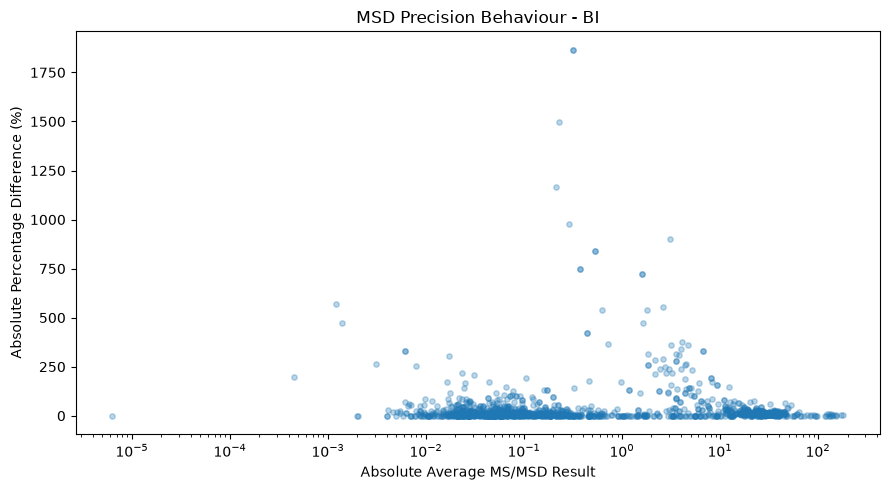

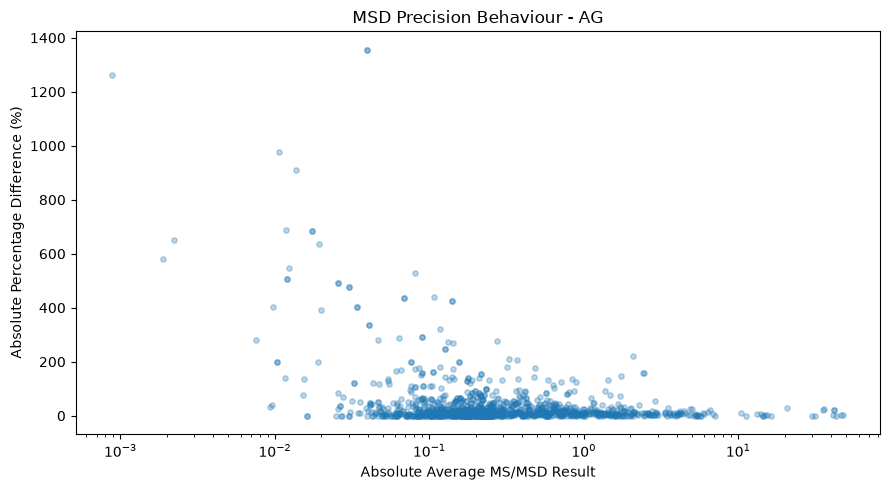

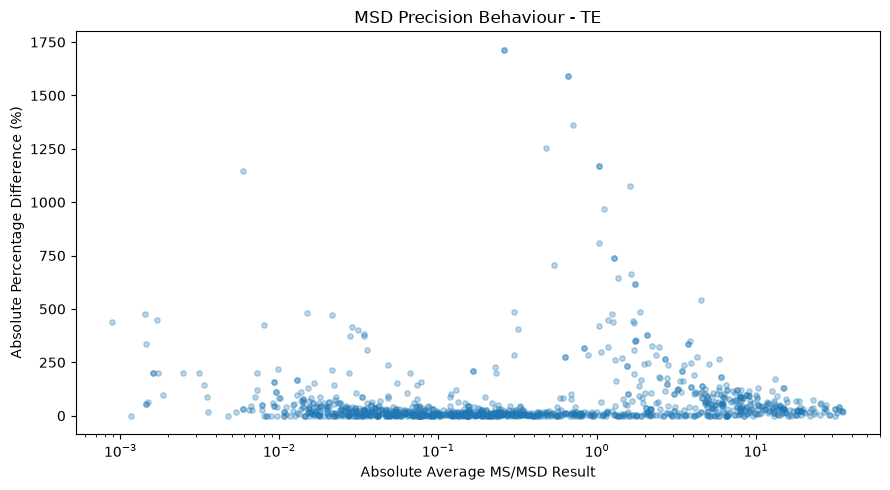

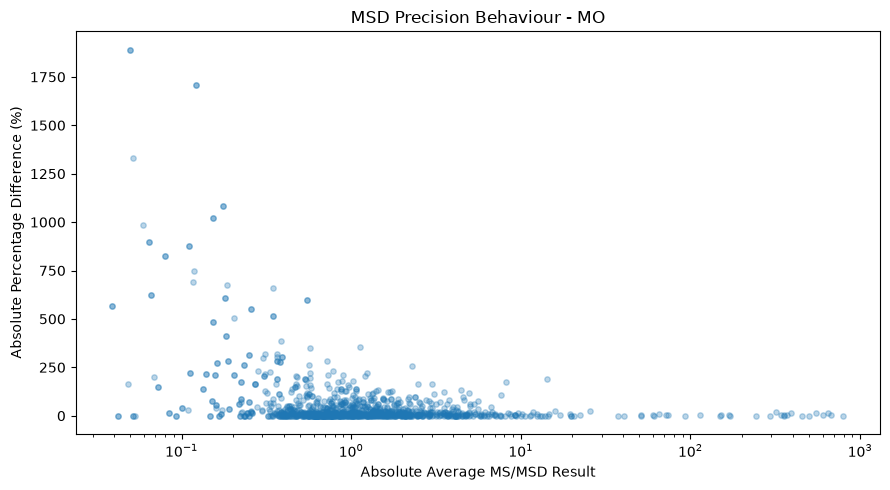

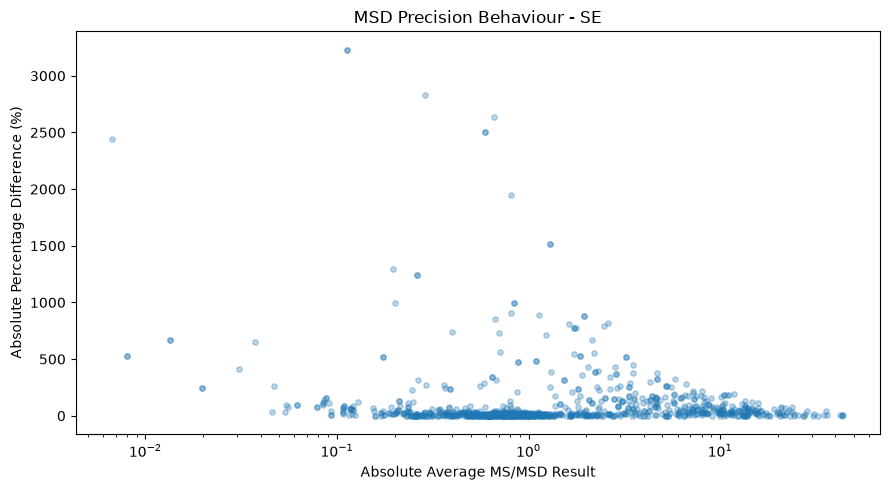

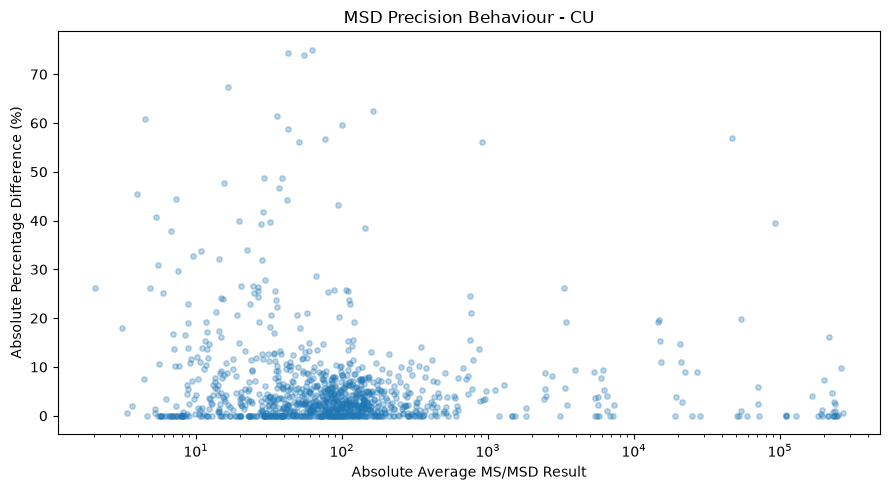

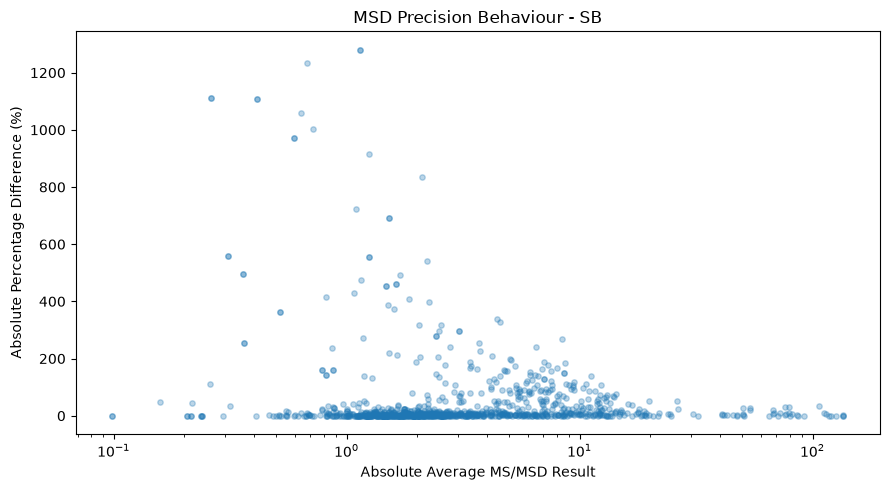

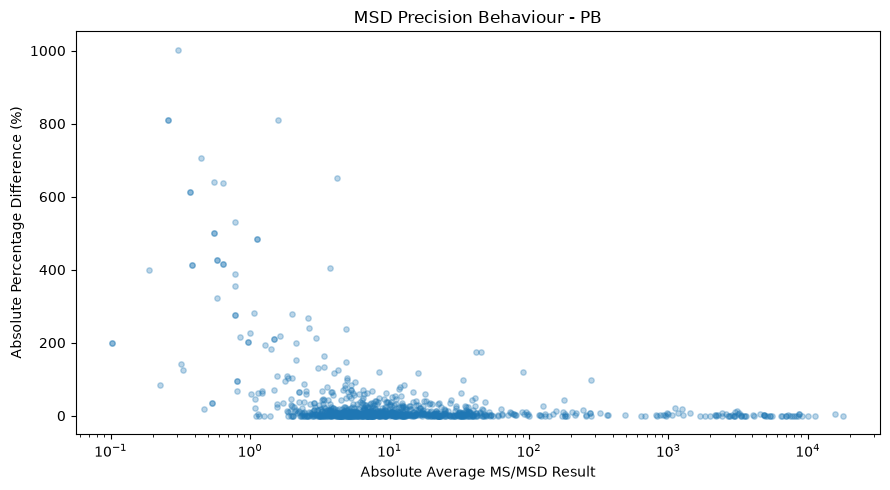

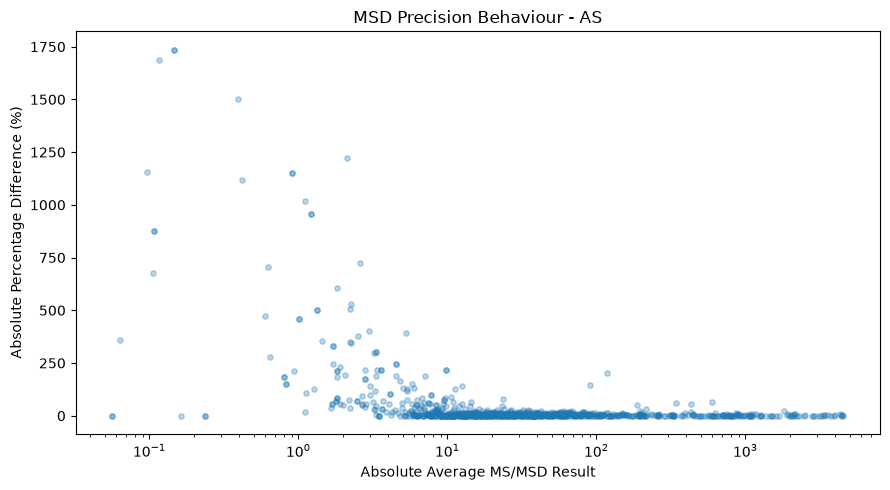

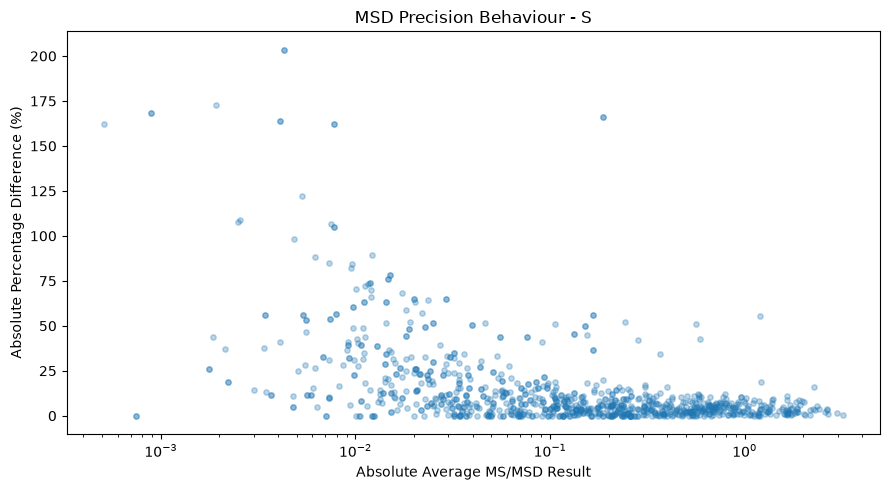

In [90]:
msd_plot = msd[
    [
        "ANALYTE_CODE",
        "Avg",
        "Abs%Diff",
        "PRECISION_STATUS"
    ]
].dropna().copy()

msd_plot["ABS_AVG"] = msd_plot["Avg"].abs()

msd_plot = msd_plot[
    msd_plot["ABS_AVG"] > 0
]

top_analytes = (
    msd_plot["ANALYTE_CODE"]
    .value_counts()
    .head(10)
    .index
)

for analyte in top_analytes:
    analyte_data = msd_plot[
        msd_plot["ANALYTE_CODE"] == analyte
    ].copy()

    x_limit = analyte_data["ABS_AVG"].quantile(0.99)
    y_limit = analyte_data["Abs%Diff"].quantile(0.99)

    plot_data = analyte_data[
        (analyte_data["ABS_AVG"] <= x_limit) &
        (analyte_data["Abs%Diff"] <= y_limit)
    ]

    plt.figure(figsize=(9, 5))

    plt.scatter(
        plot_data["ABS_AVG"],
        plot_data["Abs%Diff"],
        alpha=0.3,
        s=15
    )

    plt.xscale("log")

    plt.title(f"MSD Precision Behaviour - {analyte}")
    plt.xlabel("Absolute Average MS/MSD Result")
    plt.ylabel("Absolute Percentage Difference (%)")

    plt.tight_layout()
    plt.show()

- MSD precision changes with result magnitude.
- Lower or moderate result magnitudes often show larger percentage differences between MS and MSD.
- Higher-magnitude results are generally more tightly grouped near 0% difference.
- The amount of variability differs between analytes.
- Some analytes show much larger spread than others.
- This indicates that MSD precision is both result-magnitude dependent and analyte-specific.
- Large Abs%Diff values should therefore be interpreted in context rather than treated the same across all analytes and result ranges.
- These plots do not yet prove which points are true anomalies.
- The next step is to compare these patterns with the existing PRECISION_STATUS classifications to see which unusual points are already known Pass, Warning, Failure, or IgnoreFailure results.

These graphs show how the percentage difference between the MS and MSD pair changes with the size of the result for each analyte. Low points mean the duplicate measurements agree closely, while high points mean poorer precision. Comparing the analytes shows whether they have different precision behaviour and whether that behaviour changes with result magnitude

## 6. Existing CCLAS MSD Precision Status Across Result Magnitude

This section compares MS/MSD precision behaviour with the existing CCLAS `PRECISION_STATUS` classifications. Results are examined by analyte and result magnitude to determine where existing Pass, Warning, Failure and IgnoreFailure classifications occur.

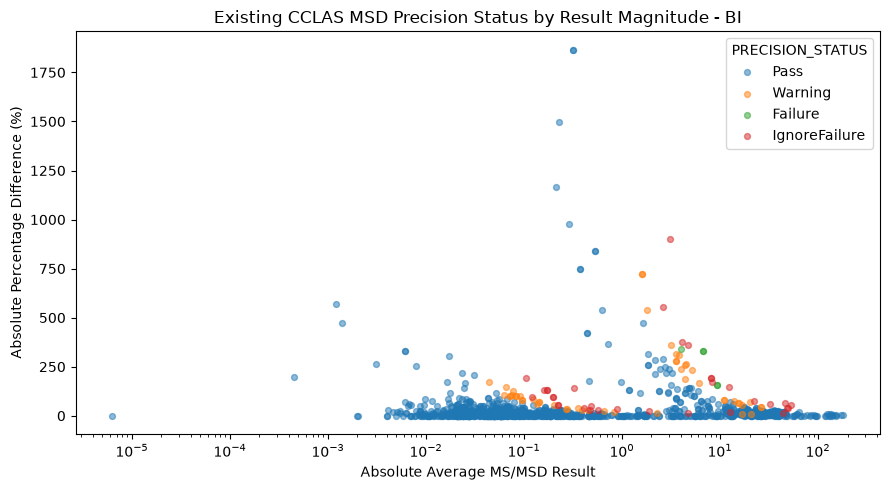

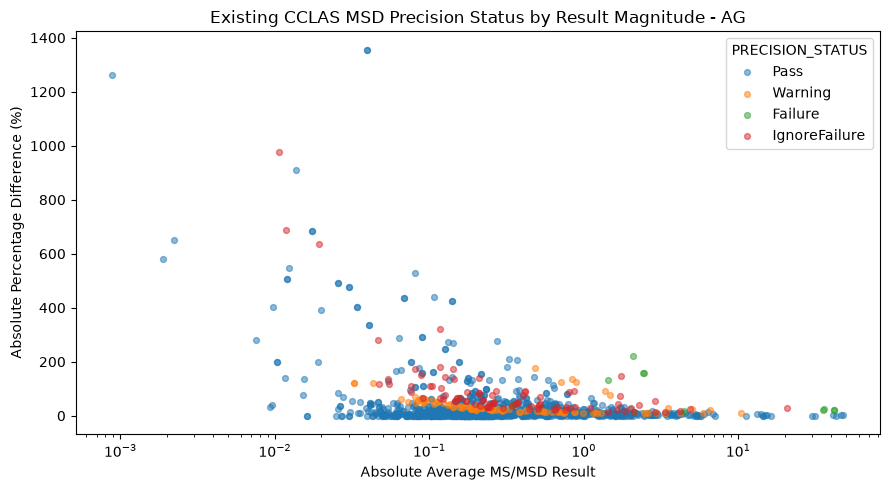

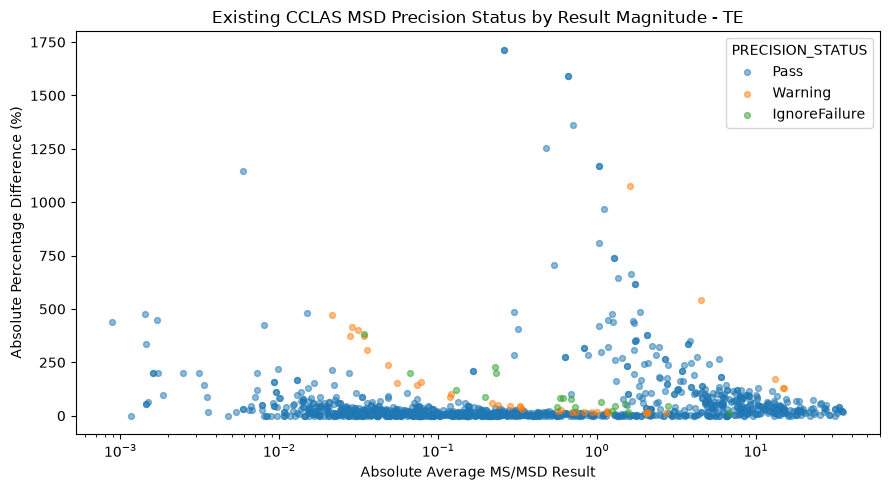

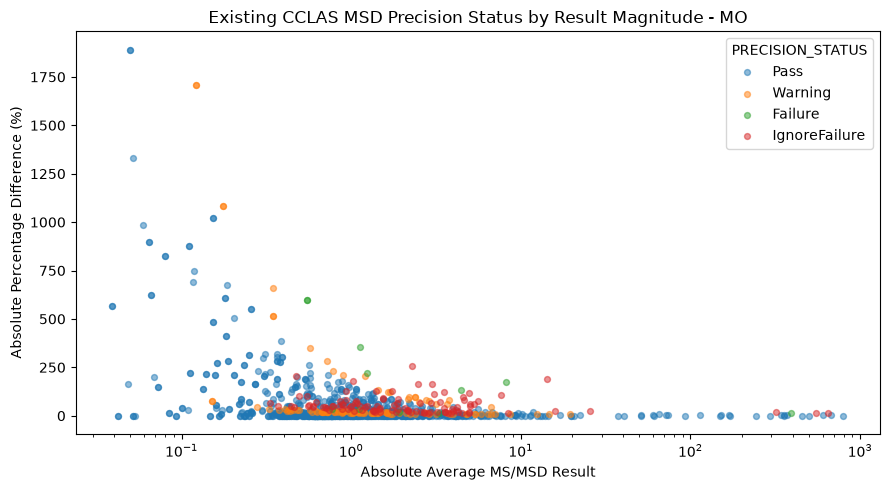

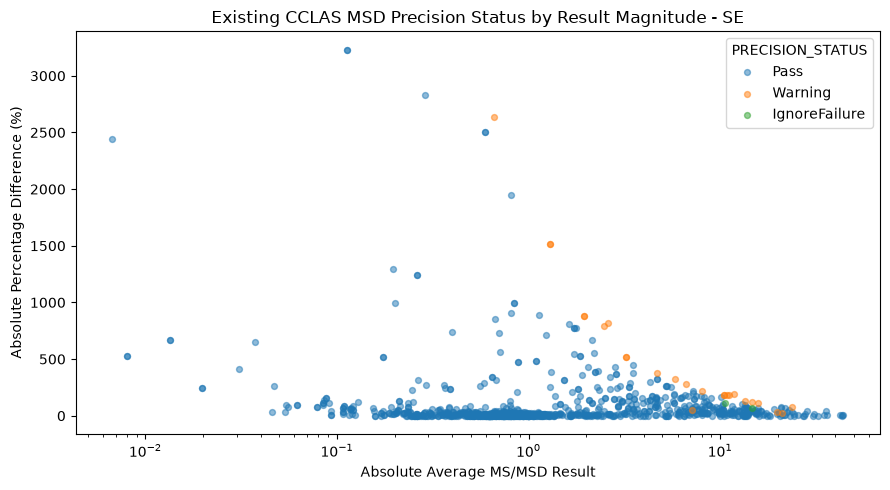

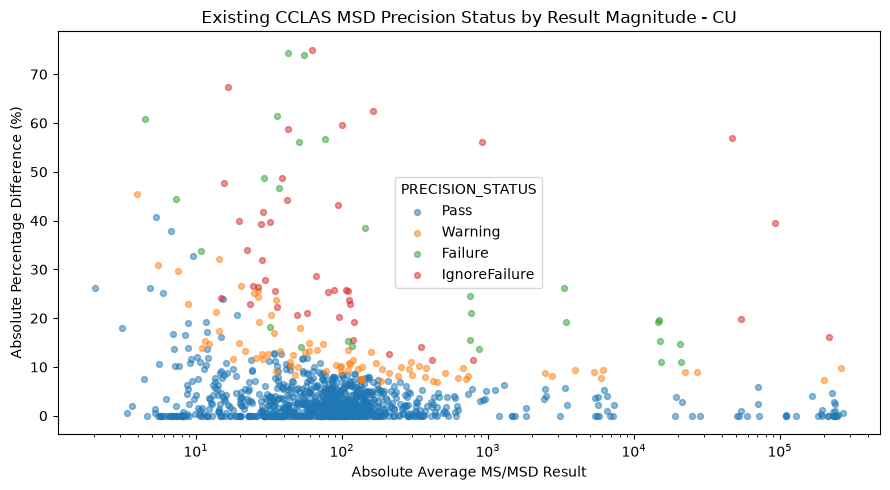

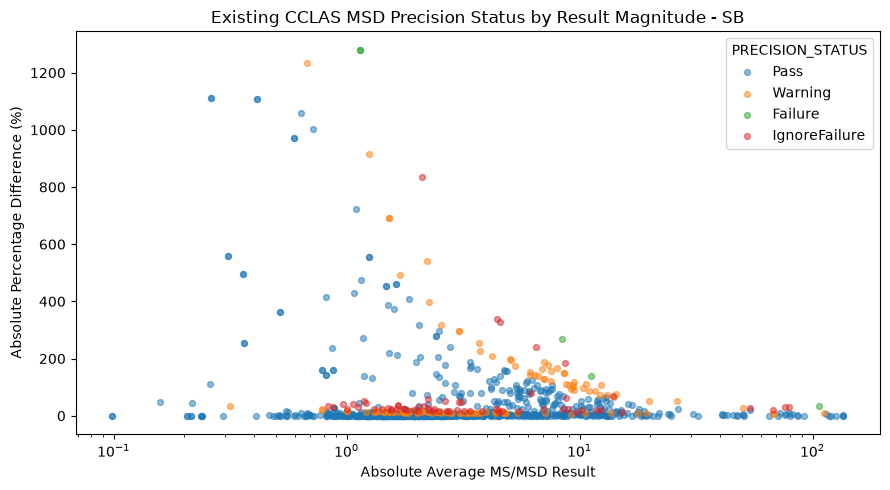

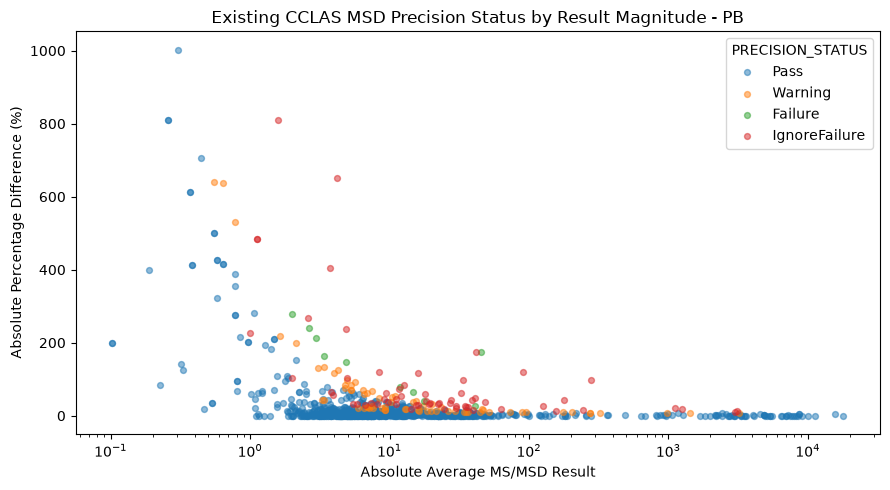

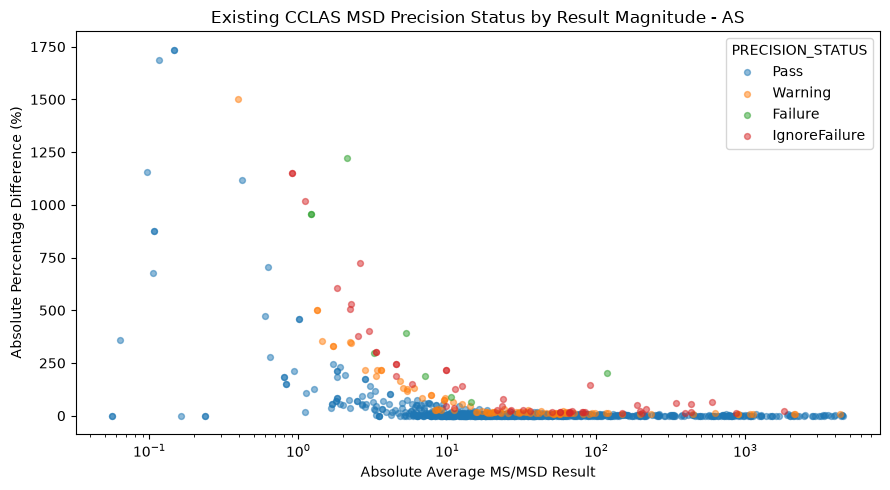

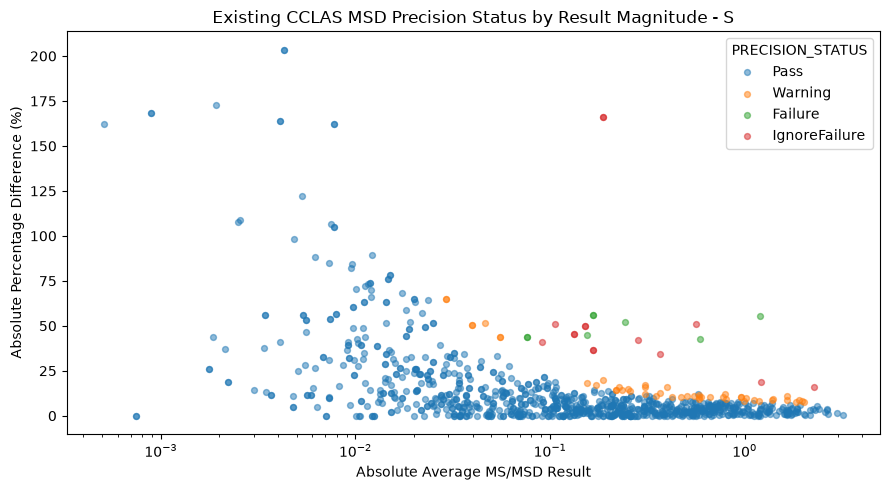

In [91]:
# Prepare MSD data for comparison with existing CCLAS precision status

status_plot = msd[
    [
        "ANALYTE_CODE",
        "Avg",
        "Abs%Diff",
        "PRECISION_STATUS"
    ]
].copy()

# Remove rows that cannot be used in this analyte-level precision plot
status_plot = status_plot.dropna(
    subset=[
        "ANALYTE_CODE",
        "Avg",
        "Abs%Diff",
        "PRECISION_STATUS"
    ]
)

# Use the absolute average MS/MSD result as result magnitude
status_plot["ABS_AVG"] = status_plot["Avg"].abs()

# Zero values cannot be displayed on a log-scaled x-axis
status_plot = status_plot[
    status_plot["ABS_AVG"] > 0
].copy()

# Focus visualisation on analytes with the most MSD observations
top_analytes = (
    status_plot["ANALYTE_CODE"]
    .value_counts()
    .head(10)
    .index
)

# Existing CCLAS precision classifications
status_order = [
    "Pass",
    "Warning",
    "Failure",
    "IgnoreFailure",
    "NotTested"
]

for analyte in top_analytes:

    analyte_data = status_plot[
        status_plot["ANALYTE_CODE"] == analyte
    ].copy()

    # Restrict the displayed range only for clearer visualisation.
    # These observations are NOT removed from the original MSD dataset.
    x_limit = analyte_data["ABS_AVG"].quantile(0.99)
    y_limit = analyte_data["Abs%Diff"].quantile(0.99)

    plot_data = analyte_data[
        (analyte_data["ABS_AVG"] <= x_limit) &
        (analyte_data["Abs%Diff"] <= y_limit)
    ]

    plt.figure(figsize=(9, 5))

    for status in status_order:

        status_data = plot_data[
            plot_data["PRECISION_STATUS"] == status
        ]

        if not status_data.empty:

            plt.scatter(
                status_data["ABS_AVG"],
                status_data["Abs%Diff"],
                alpha=0.5,
                s=18,
                label=status
            )

    plt.xscale("log")

    plt.title(
        f"Existing CCLAS MSD Precision Status by Result Magnitude - {analyte}"
    )

    plt.xlabel(
        "Absolute Average MS/MSD Result"
    )

    plt.ylabel(
        "Absolute Percentage Difference (%)"
    )

    plt.legend(
        title="PRECISION_STATUS"
    )

    plt.tight_layout()
    plt.show()

Conclude from these plots:

- Existing CCLAS precision classifications vary across analytes and result magnitudes.
- Warning, Failure and IgnoreFailure results do not occur at one universal absolute percentage difference.
- Some large relative differences remain classified as Pass, particularly within analyte- and result-magnitude-specific regions.
- This confirms that MSD precision should be interpreted using both analyte and result-magnitude context.
- The existing CCLAS classifications provide a baseline for identifying additional unusual historical or multivariate MSD behaviour in later anomaly-detection stages.

7. Historical MSD Precision Behaviour and Anomaly Candidates
The previous sections established the existing CCLAS precision classifications and showed how MS/MSD precision behaviour varies across analytes and result magnitudes. The next stage examines historical MSD precision behaviour to identify results that are unusual relative to comparable historical results, while retaining the existing CCLAS precision status as context.

In [92]:
# Prepare MSD records for historical precision analysis

historical_msd = msd[
    [
        "SCHEME_CODE",
        "ANALYTE_CODE",
        "UNIT_CODE",
        "ANALYSED_DATE",
        "Avg",
        "Abs%Diff",
        "PRECISION_STATUS"
    ]
].copy()

# Remove rows missing fields needed for comparison
historical_msd = historical_msd.dropna(
    subset=[
        "SCHEME_CODE",
        "ANALYTE_CODE",
        "UNIT_CODE",
        "ANALYSED_DATE",
        "Avg",
        "Abs%Diff"
    ]
)

# Result magnitude of the paired MS/MSD result
historical_msd["ABS_AVG"] = historical_msd["Avg"].abs()

# Remove zero magnitude because log10 cannot be calculated for zero
historical_msd = historical_msd[
    historical_msd["ABS_AVG"] > 0
].copy()

# Convert date field
historical_msd["ANALYSED_DATE"] = pd.to_datetime(
    historical_msd["ANALYSED_DATE"]
)

# Create result-magnitude bands.
# This keeps low-, medium- and high-magnitude MSD behaviour separate.
historical_msd["MAGNITUDE_BAND"] = np.floor(
    np.log10(historical_msd["ABS_AVG"])
)

print("Historical MSD rows available:", len(historical_msd))

display(
    historical_msd[
        [
            "SCHEME_CODE",
            "ANALYTE_CODE",
            "UNIT_CODE",
            "ANALYSED_DATE",
            "ABS_AVG",
            "MAGNITUDE_BAND",
            "Abs%Diff",
            "PRECISION_STATUS"
        ]
    ].head()
)

Historical MSD rows available: 22661


,SCHEME_CODE,ANALYTE_CODE,UNIT_CODE,ANALYSED_DATE,ABS_AVG,MAGNITUDE_BAND,Abs%Diff,PRECISION_STATUS
0,GE_IMS40Q12,CU,MG_KG,2021-07-20 14:17:36.000,874.773835,2.0,207.043718,IgnoreFailure
1,GE_ICP40Q12,CR,MG_KG,2021-09-02 15:51:13.000,113.494521,2.0,6.030704,Pass
2,GE_ICP40Q12,CR,MG_KG,2021-04-28 03:04:33.000,81.875446,1.0,1.783603,Pass
3,GE_ICP40Q12,BI,MG_KG,2021-03-22 06:43:40.000,65.592040,1.0,0.000000,Pass
4,GE_ICP40Q12,BI,MG_KG,2020-12-14 07:39:45.540,64.355907,1.0,18.032560,Pass


## 7. MSD Precision Behaviour Over Time

This section explores how the absolute percentage difference between paired MS/MSD results changes over time for different analytes. The aim is to examine how MSD precision behaviour is distributed through time and whether the amount of variability differs across periods.

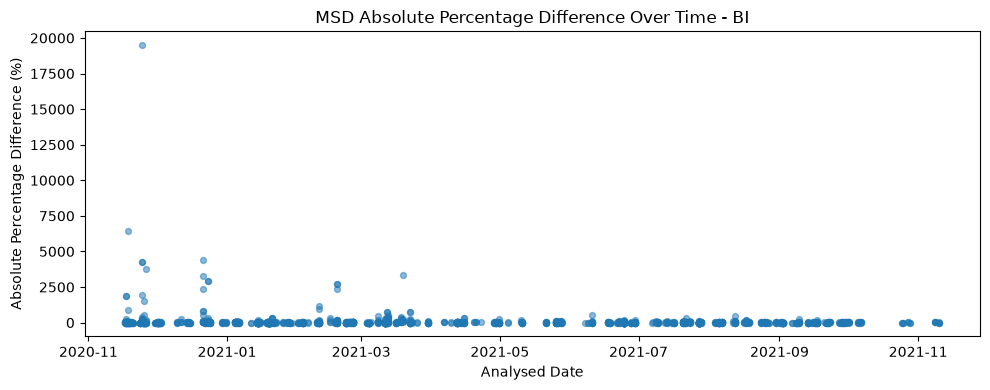

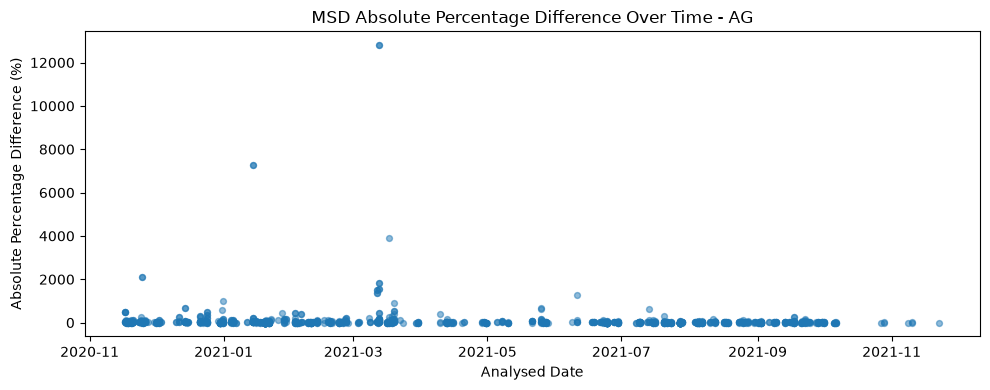

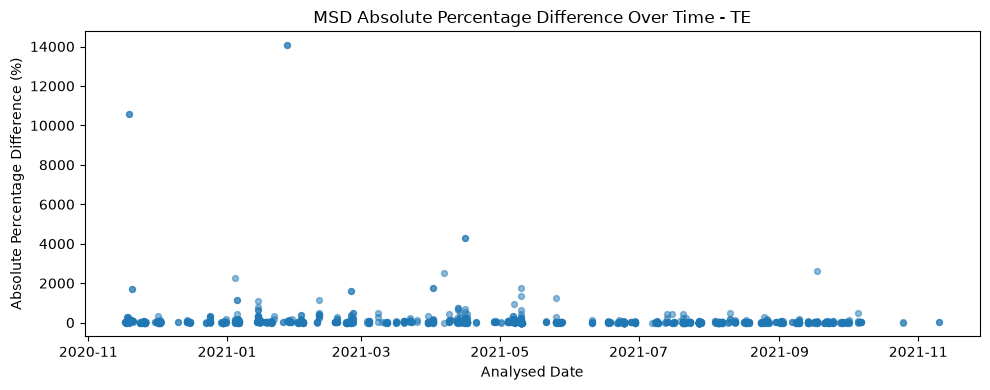

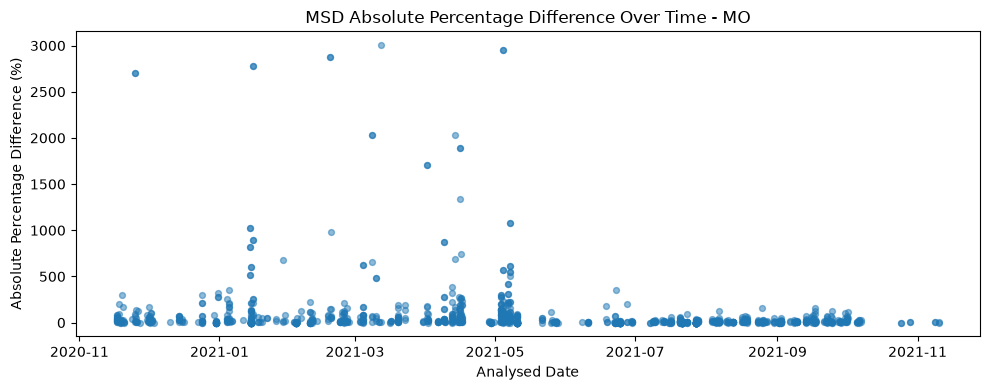

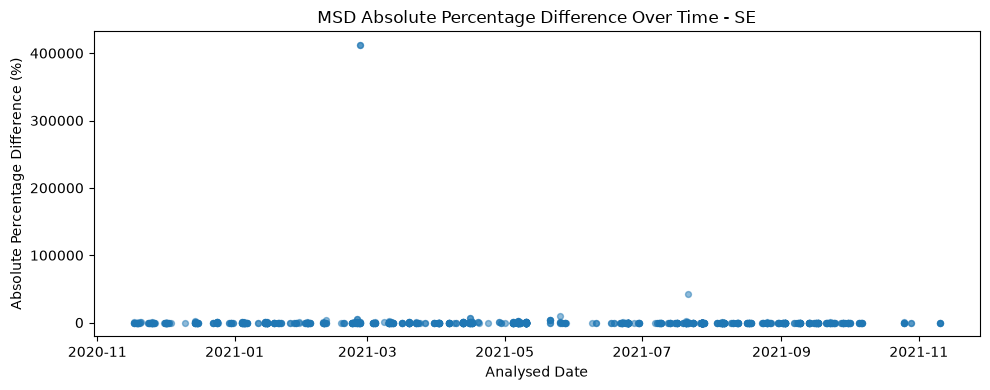

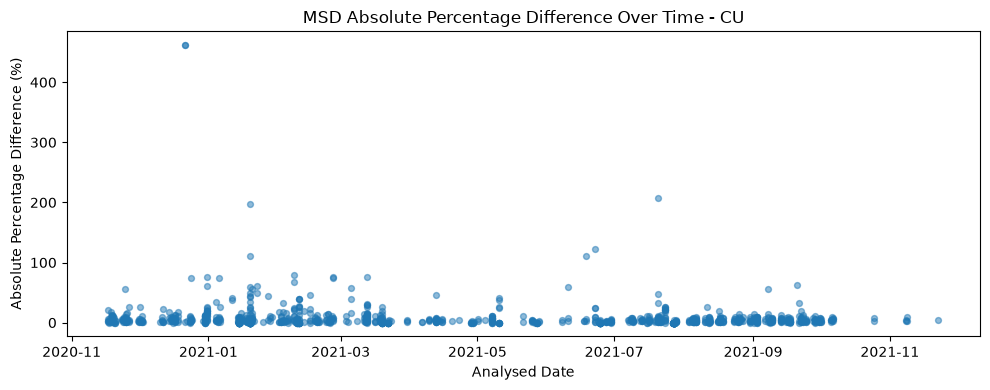

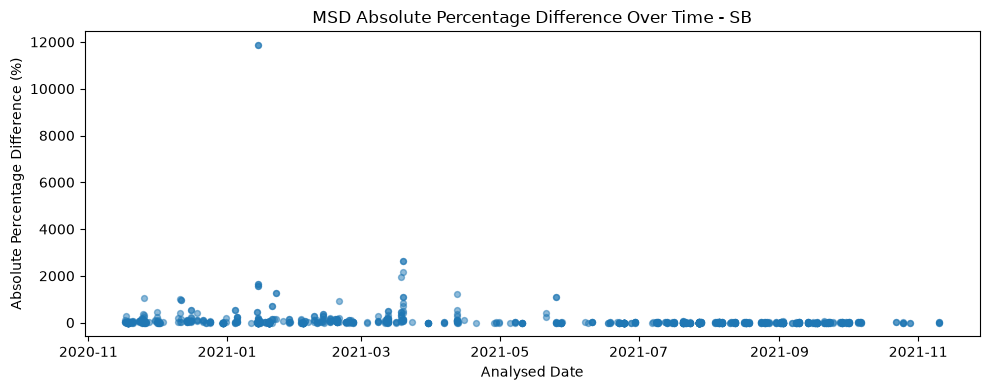

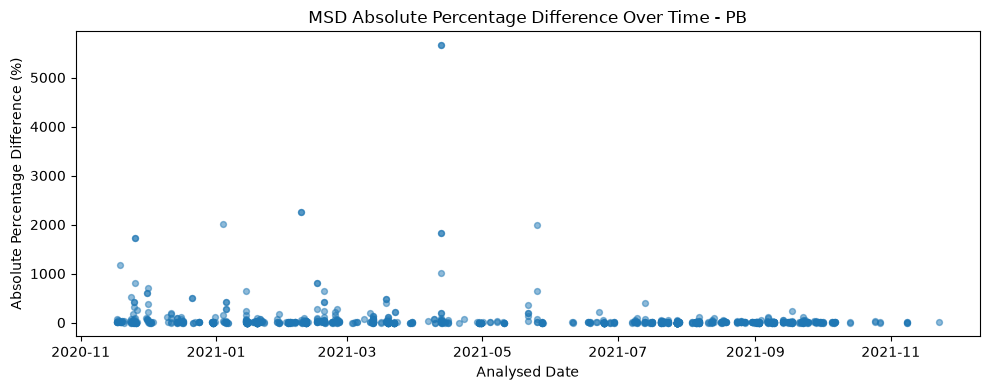

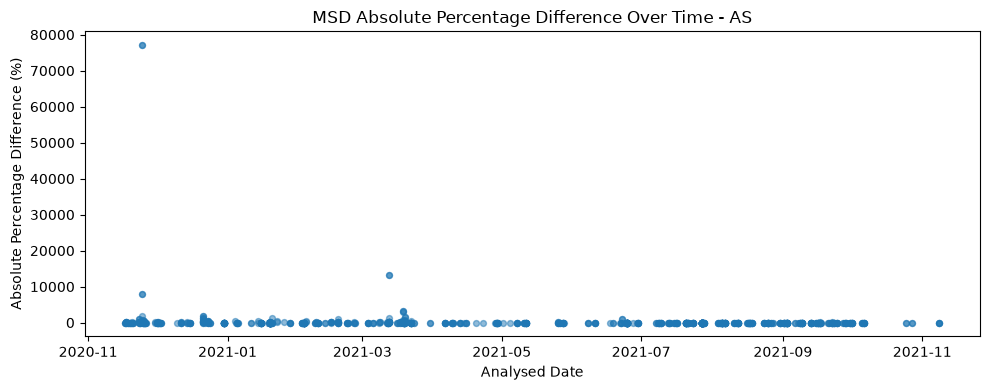

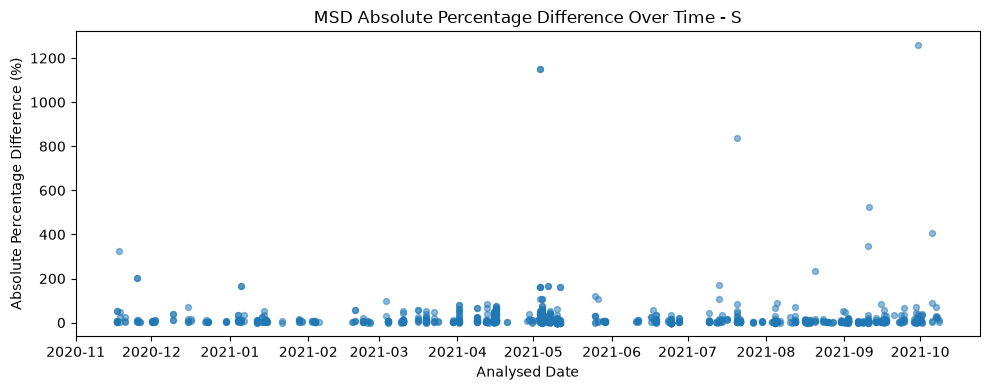

In [93]:
# Prepare MSD data for time-based exploration

time_plot = msd[
    [
        "ANALYTE_CODE",
        "ANALYSED_DATE",
        "Abs%Diff",
        "PRECISION_STATUS"
    ]
].copy()

time_plot["ANALYSED_DATE"] = pd.to_datetime(
    time_plot["ANALYSED_DATE"]
)

time_plot = time_plot.dropna(
    subset=[
        "ANALYTE_CODE",
        "ANALYSED_DATE",
        "Abs%Diff"
    ]
)

top_analytes = (
    time_plot["ANALYTE_CODE"]
    .value_counts()
    .head(10)
    .index
)

for analyte in top_analytes:

    analyte_data = time_plot[
        time_plot["ANALYTE_CODE"] == analyte
    ].sort_values("ANALYSED_DATE")

    plt.figure(figsize=(10, 4))

    plt.scatter(
        analyte_data["ANALYSED_DATE"],
        analyte_data["Abs%Diff"],
        alpha=0.5,
        s=18
    )

    plt.title(
        f"MSD Absolute Percentage Difference Over Time - {analyte}"
    )

    plt.xlabel("Analysed Date")
    plt.ylabel("Absolute Percentage Difference (%)")

    plt.tight_layout()
    plt.show()

## 8. MSD Precision Limits and Existing Status

In [94]:
# Prepare MSD data for comparison with supplied warning/failure limits

limit_data = msd[
    [
        "ANALYTE_CODE",
        "Abs%Diff",
        "Warn Limit",
        "Fail Limit",
        "PRECISION_STATUS",
        "Status"
    ]
].copy()

# Remove rows that cannot be used in the limit comparison
limit_data = limit_data.dropna(
    subset=[
        "ANALYTE_CODE",
        "Abs%Diff",
        "Warn Limit",
        "Fail Limit"
    ]
)

# Recreate the result implied by the supplied warning/failure limits
limit_data["LIMIT_STATUS"] = np.select(
    [
        limit_data["Abs%Diff"] > limit_data["Fail Limit"],
        limit_data["Abs%Diff"] > limit_data["Warn Limit"]
    ],
    [
        "Failure",
        "Warning"
    ],
    default="Pass"
)

print("Status implied by supplied MSD limits:")
display(
    limit_data["LIMIT_STATUS"]
    .value_counts()
    .rename_axis("LIMIT_STATUS")
    .reset_index(name="Count")
)

print("\nComparison with supplied Status column:")
display(
    pd.crosstab(
        limit_data["LIMIT_STATUS"],
        limit_data["Status"],
        margins=True
    )
)

print("\nComparison with existing CCLAS PRECISION_STATUS:")
display(
    pd.crosstab(
        limit_data["LIMIT_STATUS"],
        limit_data["PRECISION_STATUS"],
        margins=True
    )
)

Status implied by supplied MSD limits:


,LIMIT_STATUS,Count
0,Pass,19632
1,Failure,1565
2,Warning,1464



Comparison with supplied Status column:


Status,Failure,Pass,Warning,All
LIMIT_STATUS,,,,
Failure,1565,0,0,1565
Pass,0,19632,0,19632
Warning,0,0,1464,1464
All,1565,19632,1464,22661



Comparison with existing CCLAS PRECISION_STATUS:


PRECISION_STATUS,Failure,IgnoreFailure,NotTested,Pass,Warning,All
LIMIT_STATUS,,,,,,
Failure,329,1235,1,0,0,1565
Pass,0,0,24,19607,1,19632
Warning,0,0,0,0,1464,1464
All,329,1235,25,19607,1465,22661


### Section 8 Findings

- The status calculated from `Abs%Diff`, `Warn Limit`, and `Fail Limit` matched the supplied `Status` for all 22,661 usable MSD records.
- This shows that the supplied `Status` is consistent with the provided warning and failure limits.
- `PRECISION_STATUS` does not always match the limit-based status.
- Of the 1,565 results exceeding the failure limit, 329 are classified as `Failure`, 1,235 as `IgnoreFailure`, and 1 as `NotTested` in `PRECISION_STATUS`.
- The majority of results below the warning limit are classified as `Pass`, although a small number are `NotTested` or `Warning`.
- Therefore, `Status` and `PRECISION_STATUS` provide different information and should be kept separate in later analysis.

## 9. MSD Precision Behaviour Across Scheme and Analyte Groups

This section explores whether MSD precision behaviour differs across scheme and analyte combinations. The aim is to understand whether some groups contain more observations, greater typical percentage differences, or greater variability than others.

In [95]:
# Prepare MSD data for scheme/analyte-level exploration

group_data = msd[
    [
        "SCHEME_CODE",
        "ANALYTE_CODE",
        "UNIT_CODE",
        "Abs%Diff",
        "PRECISION_STATUS"
    ]
].dropna(
    subset=[
        "SCHEME_CODE",
        "ANALYTE_CODE",
        "Abs%Diff"
    ]
).copy()


# Summarise MSD precision behaviour within each scheme/analyte group
group_summary = (
    group_data
    .groupby(
        [
            "SCHEME_CODE",
            "ANALYTE_CODE",
            "UNIT_CODE"
        ],
        dropna=False
    )
    .agg(
        Count=("Abs%Diff", "size"),
        Median_AbsPctDiff=("Abs%Diff", "median"),
        Mean_AbsPctDiff=("Abs%Diff", "mean"),
        Std_AbsPctDiff=("Abs%Diff", "std"),
        Max_AbsPctDiff=("Abs%Diff", "max")
    )
    .reset_index()
)


# Groups with the most MSD observations
print("Scheme/analyte groups with the most MSD observations:")

display(
    group_summary
    .sort_values("Count", ascending=False)
    .head(20)
)


# Groups with the largest median percentage difference
# Restrict to groups with at least 20 observations so very small groups
# do not dominate the comparison.
print("\nGroups with the largest median Abs%Diff (minimum 20 observations):")

display(
    group_summary[
        group_summary["Count"] >= 20
    ]
    .sort_values(
        "Median_AbsPctDiff",
        ascending=False
    )
    .head(20)
)

Scheme/analyte groups with the most MSD observations:


,SCHEME_CODE,ANALYTE_CODE,UNIT_CODE,Count,Median_AbsPctDiff,Mean_AbsPctDiff,Std_AbsPctDiff,Max_AbsPctDiff
44,GE_IMS40Q12,BI,MG_KG,1049,5.857741,17.150936,39.387090,568.368561
25,GE_ICP40Q12,S,PERC,999,6.127091,20.862172,77.942906,1258.374806
40,GE_IMS40Q12,AG,MG_KG,898,7.851985,22.099076,73.252893,1262.070815
78,GE_IMS40Q12,TE,MG_KG,832,9.538853,60.522254,537.362261,10599.999888
70,GE_IMS40Q12,SB,MG_KG,759,2.165590,5.355769,9.065813,79.537230
72,GE_IMS40Q12,SE,MG_KG,754,8.729393,86.820699,1569.196136,42999.999981
12,GE_ICP40Q12,FE,PERC,735,2.311431,3.925801,9.365357,199.347780
63,GE_IMS40Q12,MO,MG_KG,735,4.559913,16.057147,112.439082,3004.138091
49,GE_IMS40Q12,CU,MG_KG,731,2.246135,5.983312,14.858472,207.043718
41,GE_IMS40Q12,AS,MG_KG,693,2.870190,5.678205,10.721979,144.671527



Groups with the largest median Abs%Diff (minimum 20 observations):


,SCHEME_CODE,ANALYTE_CODE,UNIT_CODE,Count,Median_AbsPctDiff,Mean_AbsPctDiff,Std_AbsPctDiff,Max_AbsPctDiff
26,GE_ICP40Q12,SB,MG_KG,298,83.895711,290.980315,1027.329172,11860.606061
28,GE_ICP40Q12,SE,MG_KG,363,82.293338,2602.190909,30514.824225,411809.600012
7,GE_ICP40Q12,CD,MG_KG,562,76.052073,316.616656,1240.264813,16950.000000
31,GE_ICP40Q12,TA,MG_KG,357,66.447368,320.760757,1158.337505,16452.392055
19,GE_ICP40Q12,MO,MG_KG,437,61.309280,206.349708,465.431912,2949.606299
32,GE_ICP40Q12,TE,MG_KG,398,54.601272,239.685821,1069.775564,14066.666667
35,GE_ICP40Q12,U,MG_KG,265,50.957335,168.888592,427.554065,3545.454545
0,GE_ICP40Q12,AG,MG_KG,418,30.732214,214.015698,1057.325348,12800.000002
29,GE_ICP40Q12,SN,MG_KG,168,24.858477,76.112105,223.710334,1790.909091
45,GE_IMS40Q12,CD,MG_KG,74,24.253820,46.301286,93.722600,592.417062


### Section 9 Findings

- MSD precision behaviour differs substantially across scheme and analyte groups.
- Some scheme/analyte combinations have much larger median absolute percentage differences than others.
- Several groups also show large differences between their median and mean `Abs%Diff`, together with large standard deviations and maximum values.
- This shows that the distribution and variability of MSD precision are not consistent across all scheme/analyte groups.
- Groups with the largest typical percentage differences include several `GE_ICP40Q12` analytes such as SB, SE, CD, TA, MO and TE.
- These results support analysing MSD behaviour within comparable scheme/analyte groups rather than treating all MSD observations as one common distribution.
- The large values identified here are descriptive observations only and are not yet classified as anomalies.

## 10. Paired MS/MSD Result Behaviour

This section explores the relationship between the paired MS and MSD result values. The aim is to understand how closely the paired measurements agree and whether the amount of difference varies between analytes.

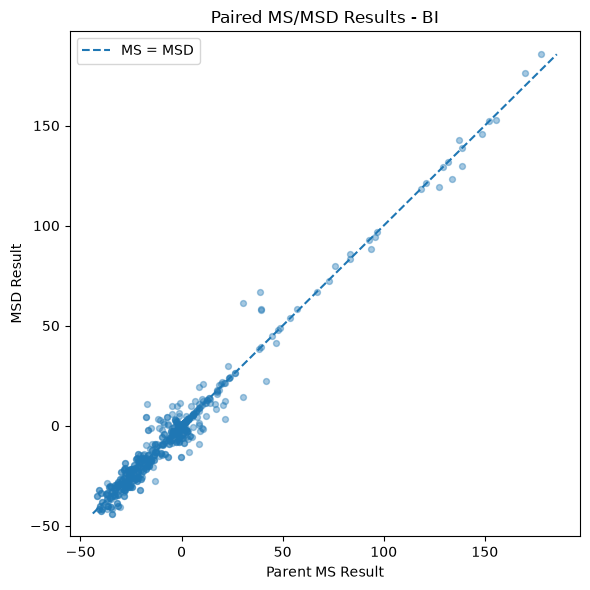

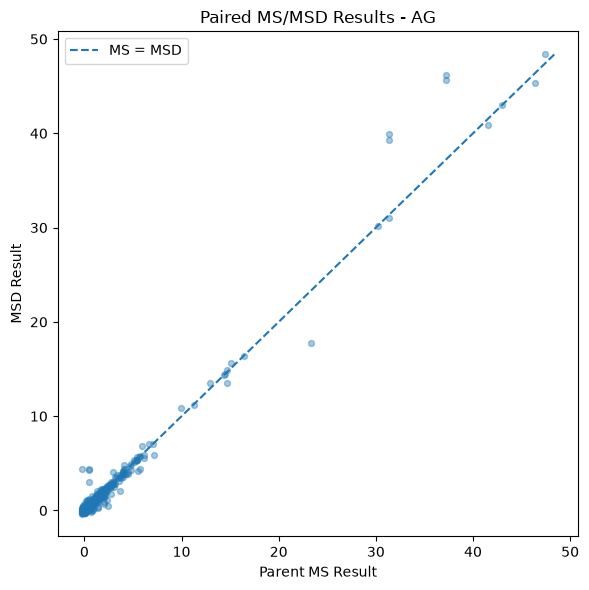

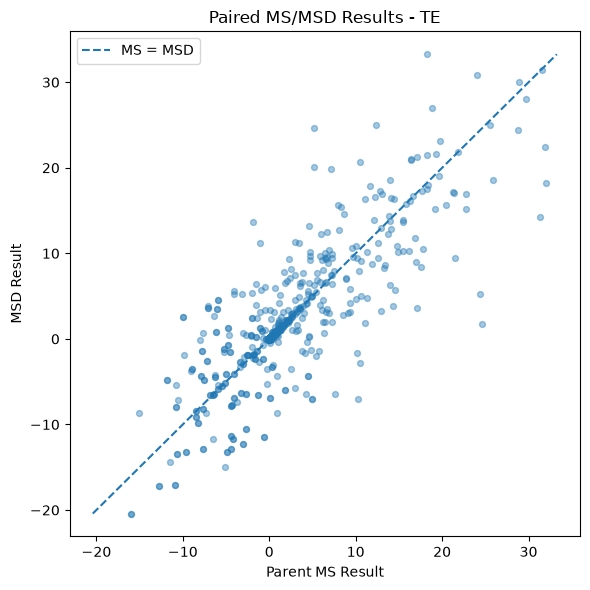

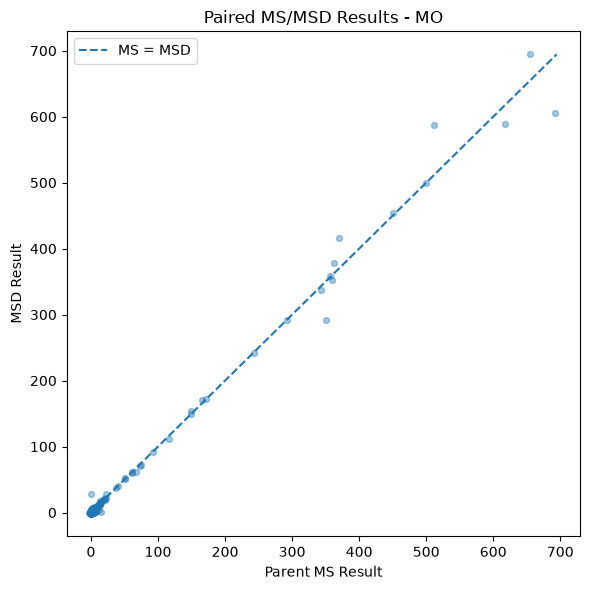

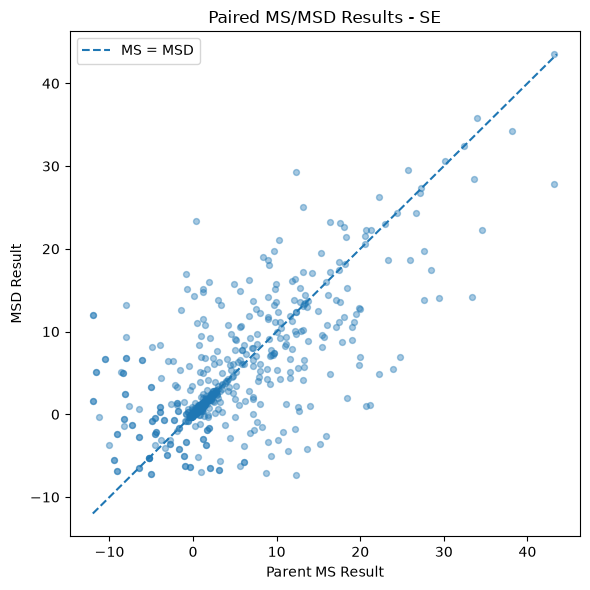

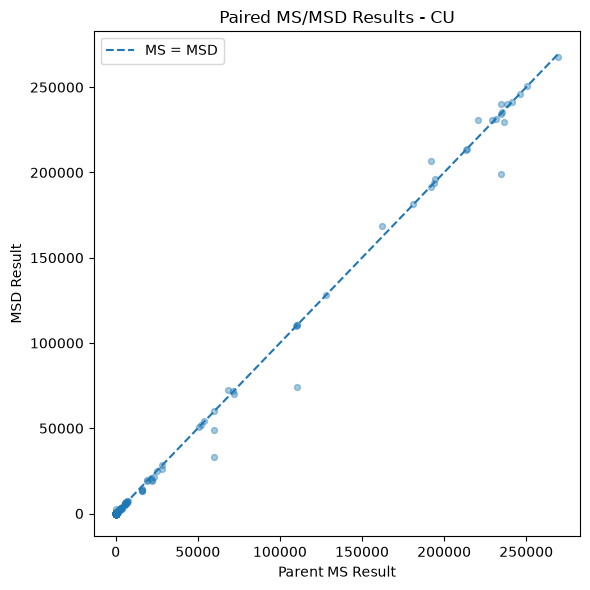

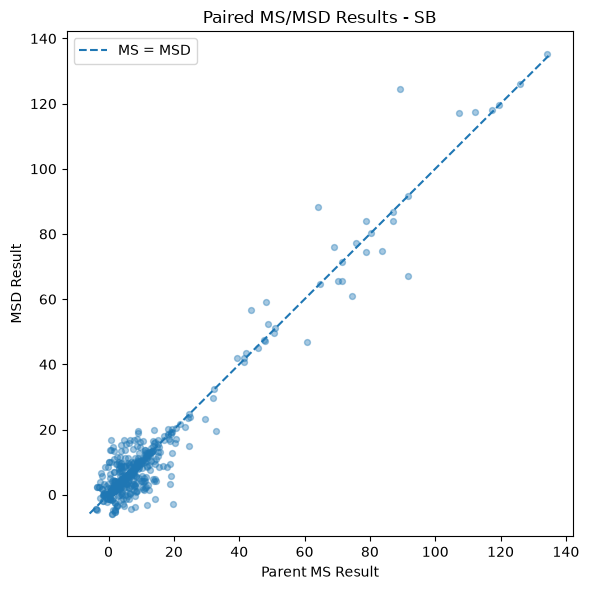

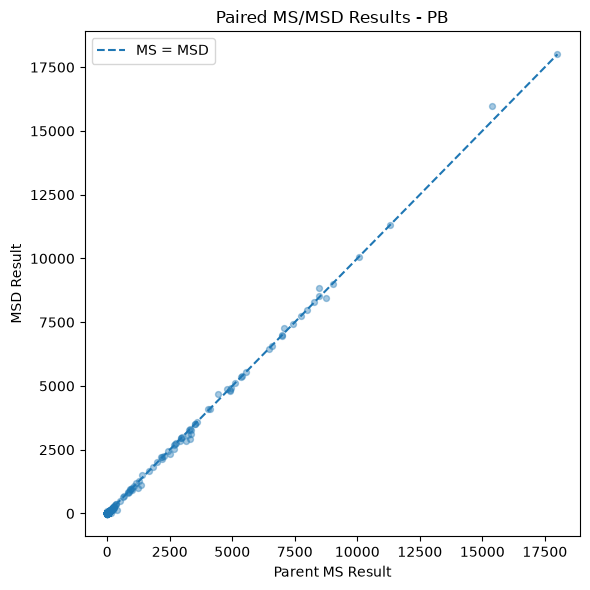

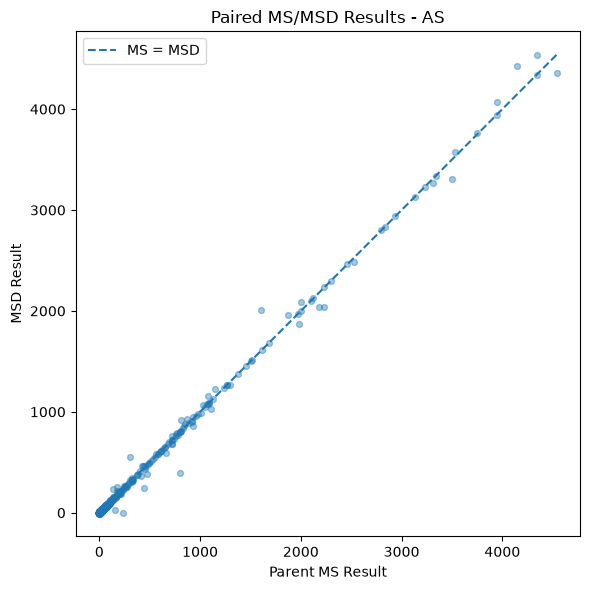

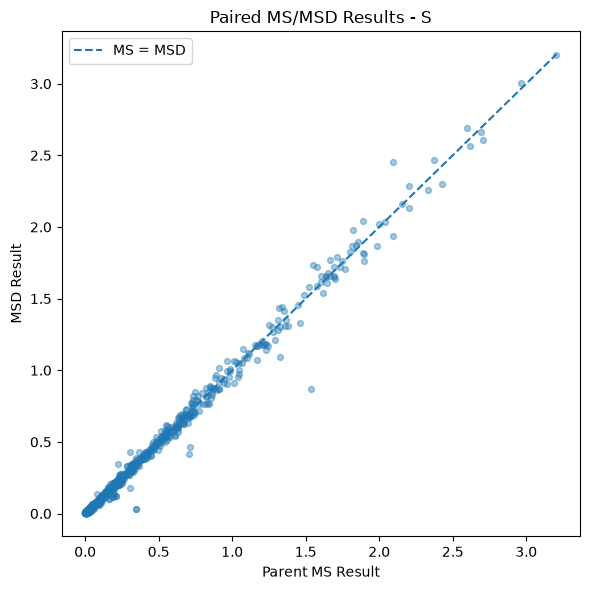

In [96]:
# Prepare paired MS/MSD result data

paired_data = msd[
    [
        "ANALYTE_CODE",
        "NUMERIC_FINAL_VALUE",
        "PARENT_NUMERIC_FINAL_VALUE",
        "AbsDiff",
        "Abs%Diff"
    ]
].dropna(
    subset=[
        "ANALYTE_CODE",
        "NUMERIC_FINAL_VALUE",
        "PARENT_NUMERIC_FINAL_VALUE"
    ]
).copy()

# Focus on analytes with the most paired observations
top_analytes = (
    paired_data["ANALYTE_CODE"]
    .value_counts()
    .head(10)
    .index
)

for analyte in top_analytes:

    analyte_data = paired_data[
        paired_data["ANALYTE_CODE"] == analyte
    ].copy()

    # Restrict displayed range only for visual clarity
    x_low = analyte_data["PARENT_NUMERIC_FINAL_VALUE"].quantile(0.01)
    x_high = analyte_data["PARENT_NUMERIC_FINAL_VALUE"].quantile(0.99)

    y_low = analyte_data["NUMERIC_FINAL_VALUE"].quantile(0.01)
    y_high = analyte_data["NUMERIC_FINAL_VALUE"].quantile(0.99)

    plot_data = analyte_data[
        (analyte_data["PARENT_NUMERIC_FINAL_VALUE"] >= x_low) &
        (analyte_data["PARENT_NUMERIC_FINAL_VALUE"] <= x_high) &
        (analyte_data["NUMERIC_FINAL_VALUE"] >= y_low) &
        (analyte_data["NUMERIC_FINAL_VALUE"] <= y_high)
    ]

    plt.figure(figsize=(6, 6))

    plt.scatter(
        plot_data["PARENT_NUMERIC_FINAL_VALUE"],
        plot_data["NUMERIC_FINAL_VALUE"],
        alpha=0.4,
        s=18
    )

    # 1:1 reference line representing equal MS and MSD results
    line_min = min(
        plot_data["PARENT_NUMERIC_FINAL_VALUE"].min(),
        plot_data["NUMERIC_FINAL_VALUE"].min()
    )

    line_max = max(
        plot_data["PARENT_NUMERIC_FINAL_VALUE"].max(),
        plot_data["NUMERIC_FINAL_VALUE"].max()
    )

    plt.plot(
        [line_min, line_max],
        [line_min, line_max],
        linestyle="--",
        label="MS = MSD"
    )

    plt.title(
        f"Paired MS/MSD Results - {analyte}"
    )

    plt.xlabel("Parent MS Result")
    plt.ylabel("MSD Result")

    plt.legend()
    plt.tight_layout()
    plt.show()

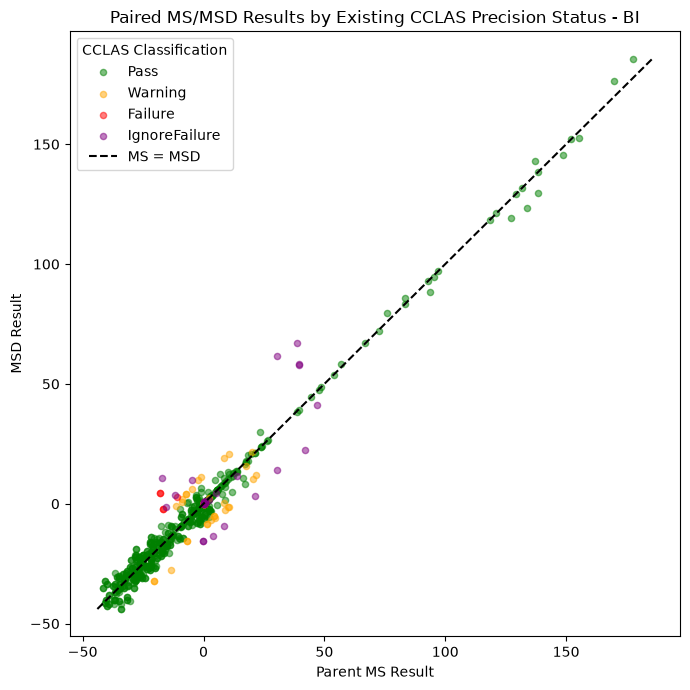

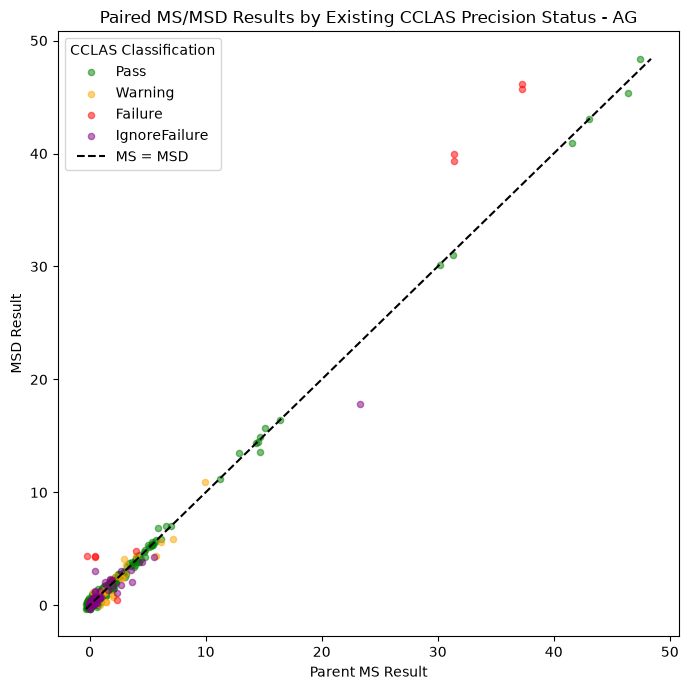

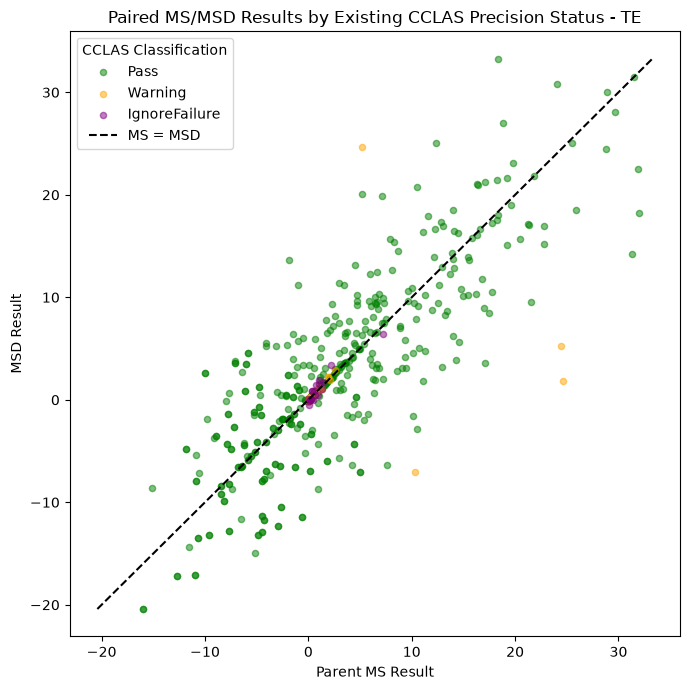

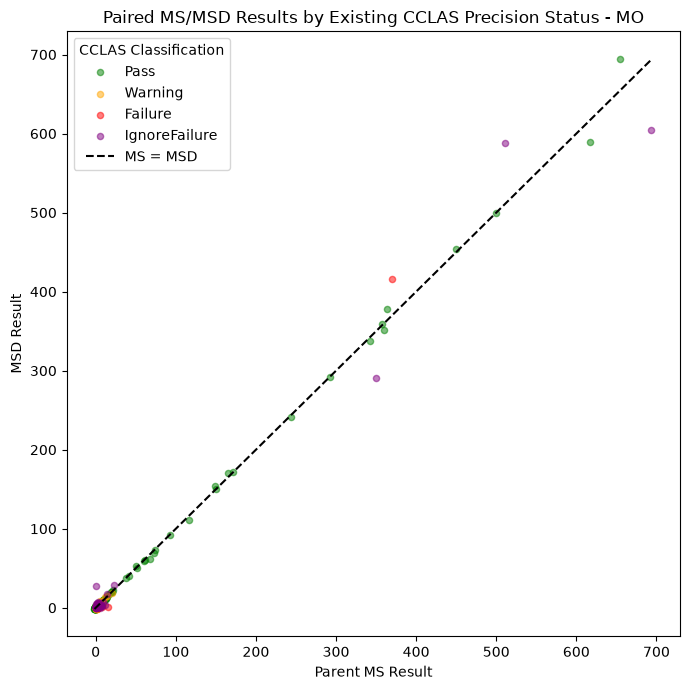

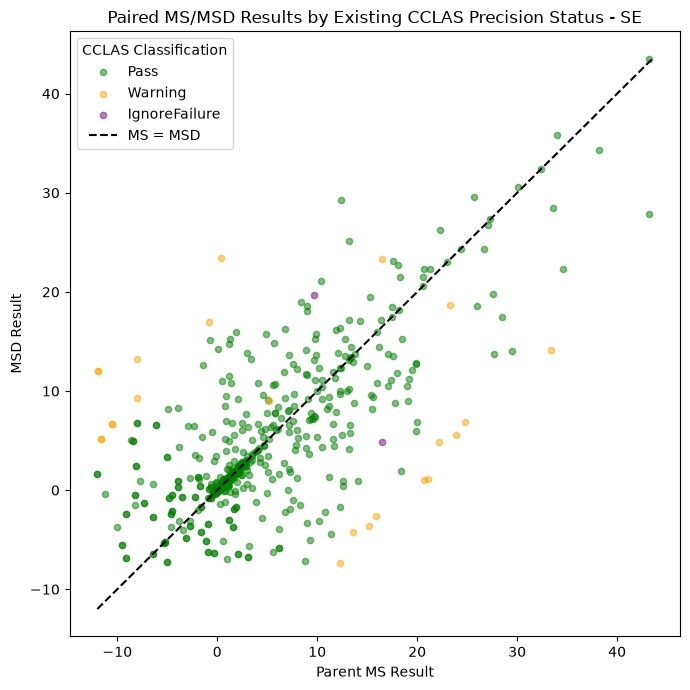

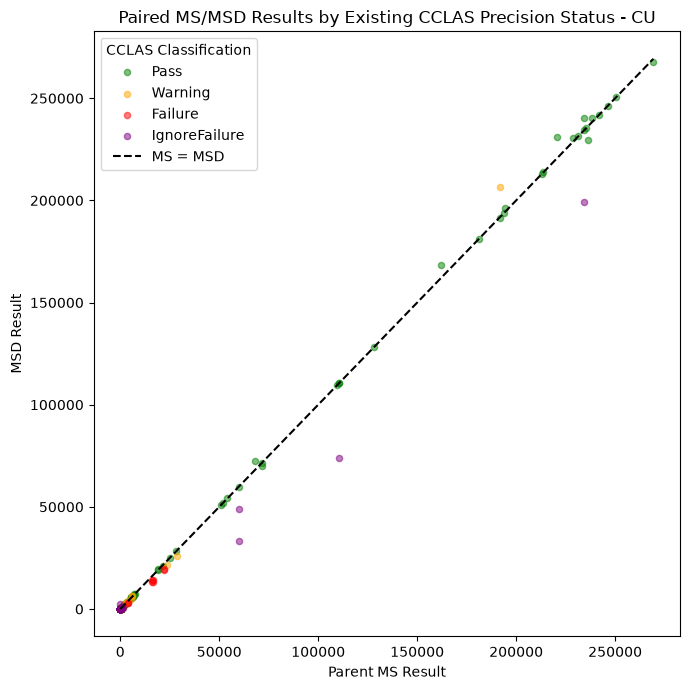

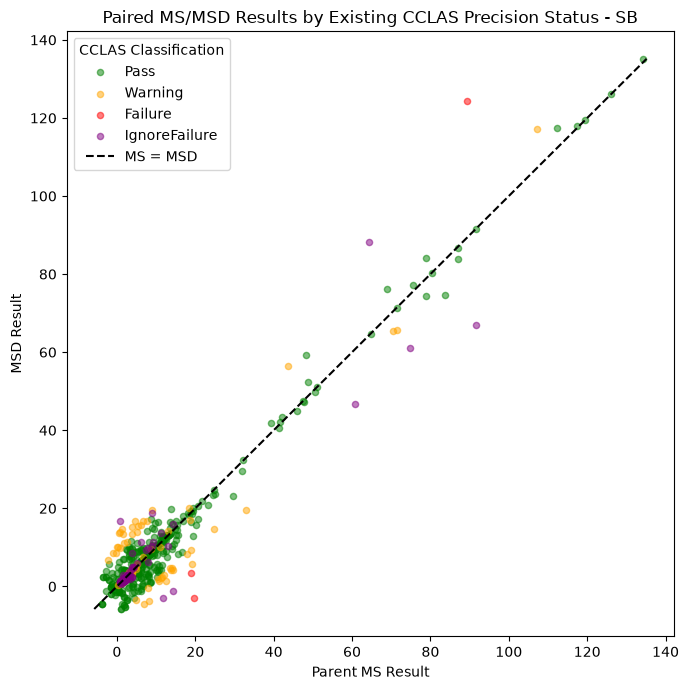

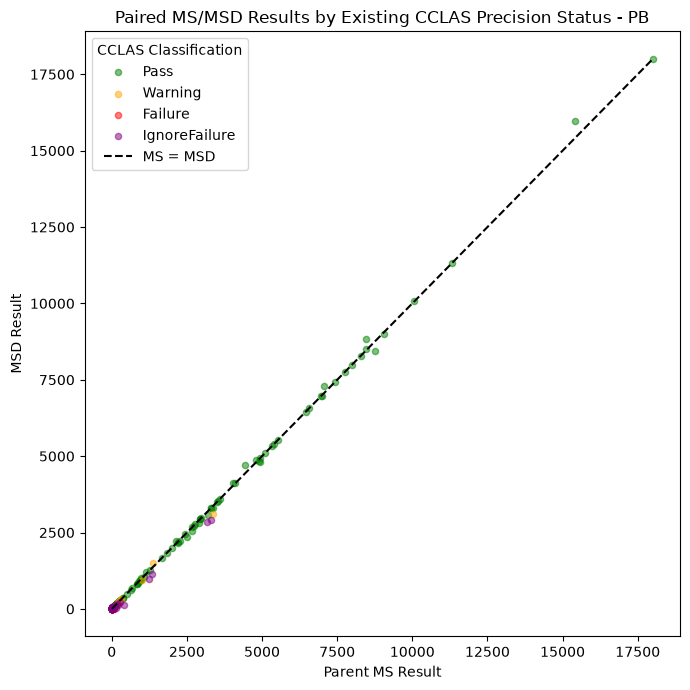

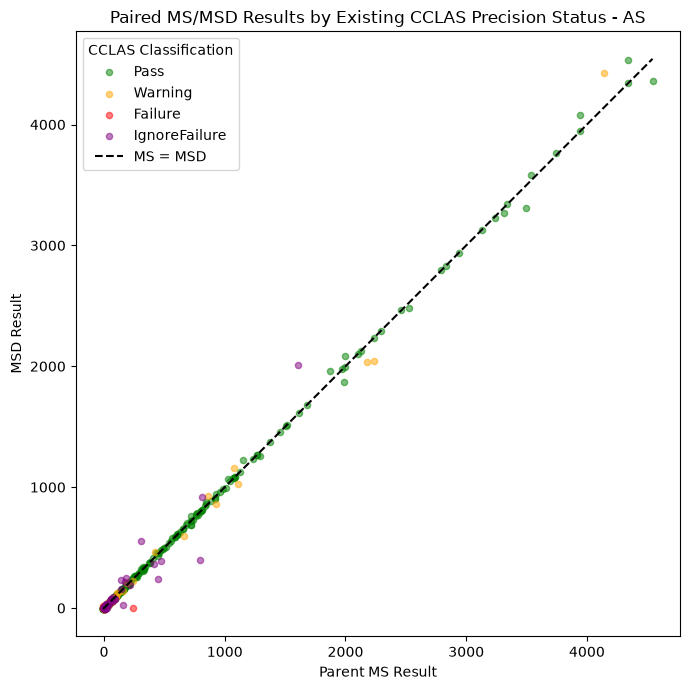

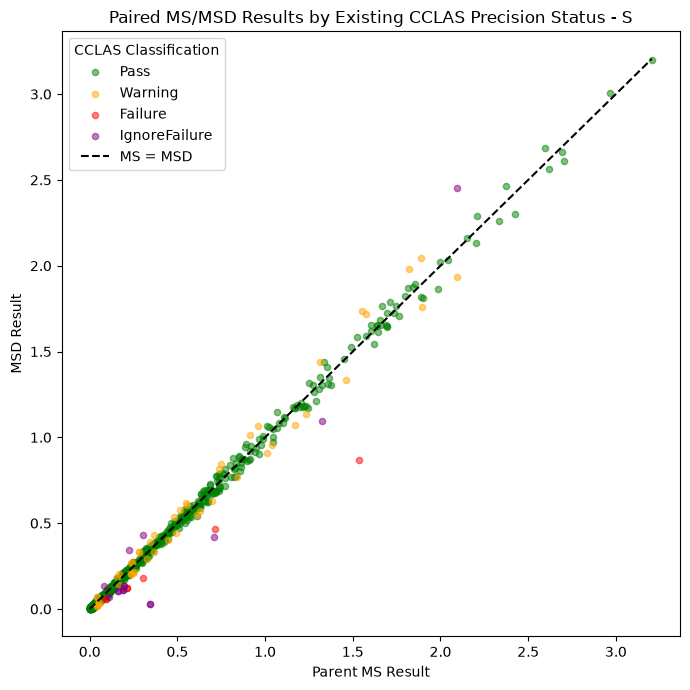

In [97]:
# Prepare paired MS/MSD result data

paired_data = msd[
    [
        "ANALYTE_CODE",
        "NUMERIC_FINAL_VALUE",
        "PARENT_NUMERIC_FINAL_VALUE",
        "AbsDiff",
        "Abs%Diff",
        "PRECISION_STATUS"
    ]
].dropna(
    subset=[
        "ANALYTE_CODE",
        "NUMERIC_FINAL_VALUE",
        "PARENT_NUMERIC_FINAL_VALUE",
        "PRECISION_STATUS"
    ]
).copy()

# Focus on analytes with the most paired observations
top_analytes = (
    paired_data["ANALYTE_CODE"]
    .value_counts()
    .head(10)
    .index
)

# Fixed colour mapping for existing CCLAS precision classifications
status_colours = {
    "Pass": "green",
    "Warning": "orange",
    "Failure": "red",
    "IgnoreFailure": "purple",
    "NotTested": "gray"
}

for analyte in top_analytes:

    analyte_data = paired_data[
        paired_data["ANALYTE_CODE"] == analyte
    ].copy()

    # Restrict displayed range only for visual clarity
    x_low = analyte_data["PARENT_NUMERIC_FINAL_VALUE"].quantile(0.01)
    x_high = analyte_data["PARENT_NUMERIC_FINAL_VALUE"].quantile(0.99)

    y_low = analyte_data["NUMERIC_FINAL_VALUE"].quantile(0.01)
    y_high = analyte_data["NUMERIC_FINAL_VALUE"].quantile(0.99)

    plot_data = analyte_data[
        (analyte_data["PARENT_NUMERIC_FINAL_VALUE"] >= x_low) &
        (analyte_data["PARENT_NUMERIC_FINAL_VALUE"] <= x_high) &
        (analyte_data["NUMERIC_FINAL_VALUE"] >= y_low) &
        (analyte_data["NUMERIC_FINAL_VALUE"] <= y_high)
    ]

    plt.figure(figsize=(7, 7))

    # Plot each CCLAS status separately
    for status, colour in status_colours.items():

        status_data = plot_data[
            plot_data["PRECISION_STATUS"] == status
        ]

        if len(status_data) == 0:
            continue

        plt.scatter(
            status_data["PARENT_NUMERIC_FINAL_VALUE"],
            status_data["NUMERIC_FINAL_VALUE"],
            alpha=0.5,
            s=20,
            color=colour,
            label=status
        )

    # 1:1 reference line representing equal MS and MSD results
    line_min = min(
        plot_data["PARENT_NUMERIC_FINAL_VALUE"].min(),
        plot_data["NUMERIC_FINAL_VALUE"].min()
    )

    line_max = max(
        plot_data["PARENT_NUMERIC_FINAL_VALUE"].max(),
        plot_data["NUMERIC_FINAL_VALUE"].max()
    )

    plt.plot(
        [line_min, line_max],
        [line_min, line_max],
        linestyle="--",
        color="black",
        label="MS = MSD"
    )

    plt.title(
        f"Paired MS/MSD Results by Existing CCLAS Precision Status - {analyte}"
    )

    plt.xlabel("Parent MS Result")
    plt.ylabel("MSD Result")

    plt.legend(
        title="CCLAS Classification"
    )

    plt.tight_layout()
    plt.show()

### Section 10 Findings

- The paired MS and MSD results generally show a positive relationship, with higher parent MS results associated with higher MSD results.
- The degree of agreement differs between analytes.
- Several of the displayed analytes show paired results concentrated close to the MS = MSD reference line, while others show greater scatter around this relationship.
- TE and SE show visibly greater spread between paired measurements than several of the other displayed analytes.
- These plots describe the underlying paired measurements used in MSD precision assessment and do not by themselves identify anomalous results.

In [98]:
# Prepare paired MS/MSD result data with existing CCLAS precision status

paired_data = msd[
    [
        "ANALYTE_CODE",
        "NUMERIC_FINAL_VALUE",
        "PARENT_NUMERIC_FINAL_VALUE",
        "AbsDiff",
        "Abs%Diff",
        "PRECISION_STATUS"
    ]
].dropna(
    subset=[
        "ANALYTE_CODE",
        "NUMERIC_FINAL_VALUE",
        "PARENT_NUMERIC_FINAL_VALUE",
        "PRECISION_STATUS"
    ]
).copy()

# Focus on analytes with the most paired observations
top_analytes = (
    paired_data["ANALYTE_CODE"]
    .value_counts()
    .head(10)
    .index
)

# Existing CCLAS precision classifications
status_order = [
    "Pass",
    "Warning",
    "Failure",
    "IgnoreFailure",
    "NotTested"
]

for analyte in top_analytes:

    analyte_data = paired_data[
        paired_data["ANALYTE_CODE"] == analyte
    ].copy()

    # Restrict displayed range only for visual clarity
    x_low = analyte_data[
        "PARENT_NUMERIC_FINAL_VALUE"
    ].quantile(0.01)

    x_high = analyte_data[
        "PARENT_NUMERIC_FINAL_VALUE"
    ].quantile(0.99)

    y_low = analyte_data[
        "NUMERIC_FINAL_VALUE"
    ].quantile(0.01)

    y_high = analyte_data[
        "NUMERIC_FINAL_VALUE"
    ].quantile(0.99)

    plot_data = analyte_data[
        (analyte_data["PARENT_NUMERIC_FINAL_VALUE"] >= x_low) &
        (analyte_data["PARENT_NUMERIC_FINAL_VALUE"] <= x_high) &
        (analyte_data["NUMERIC_FINAL_VALUE"] >= y_low) &
        (analyte_data["NUMERIC_FINAL_VALUE"] <= y_high)
    ].copy()

    plt.figure(figsize=(7, 7))

    # Plot each existing CCLAS precision status separately
    for status in status_order:

        status_data = plot_data[
            plot_data["PRECISION_STATUS"] == status
        ]

        if not status_data.empty:

            plt.scatter(
                status_data["PARENT_NUMERIC_FINAL_VALUE"],
                status_data["NUMERIC_FINAL_VALUE"],
                alpha=0.5,
                s=20,
                label=status
            )

    # 1:1 reference line representing equal MS and MSD results
    line_min = min(
        plot_data["PARENT_NUMERIC_FINAL_VALUE"].min(),
        plot_data["NUMERIC_FINAL_VALUE"].min()
    )

    line_max = max(
        plot_data["PARENT_NUMERIC_FINAL_VALUE"].max(),
        plot_data["NUMERIC_FINAL_VALUE"].max()
    )

    plt.plot(
        [line_min, line_max],
        [line_min, line_max],
        linestyle="--",
        label="MS = MSD"
    )

    plt.title(
        f"Paired MS/MSD Results by Existing CCLAS Precision Status - {analyte}"
    )

    plt.xlabel("Parent MS Result")
    plt.ylabel("MSD Result")

    plt.legend(
        title="CCLAS Classification"
    )

    plt.tight_layout()
    plt.show()t

SyntaxError: invalid syntax (2484428142.py, line 117)

The EDA shows that MSD precision is analyte- and magnitude-dependent. Different analytes have different levels of normal variation, so the historical reference model needs to account for analytical context rather than applying one universal threshold across all MSD results.

## 11. MSD Mean and Variability Behaviour

This section explores how the difference between paired MS/MSD results changes across the average result magnitude. The aim is to examine whether the amount of variation between paired measurements remains consistent across different result magnitudes and analytes.

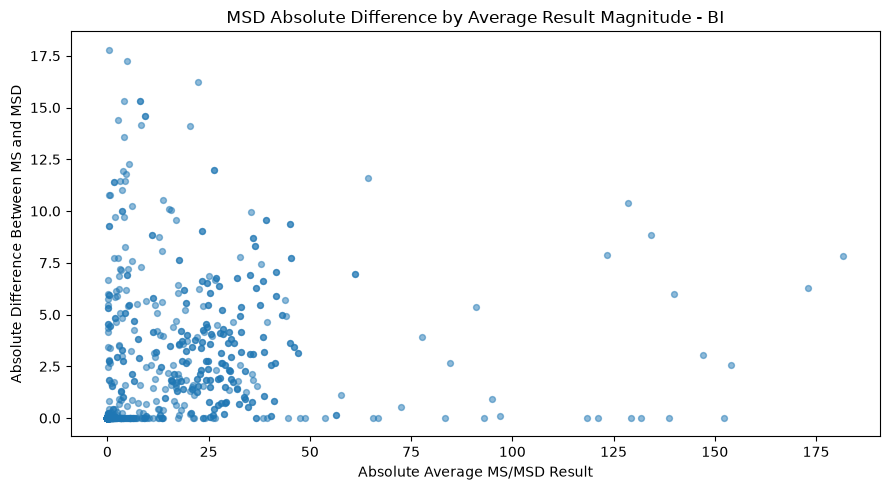

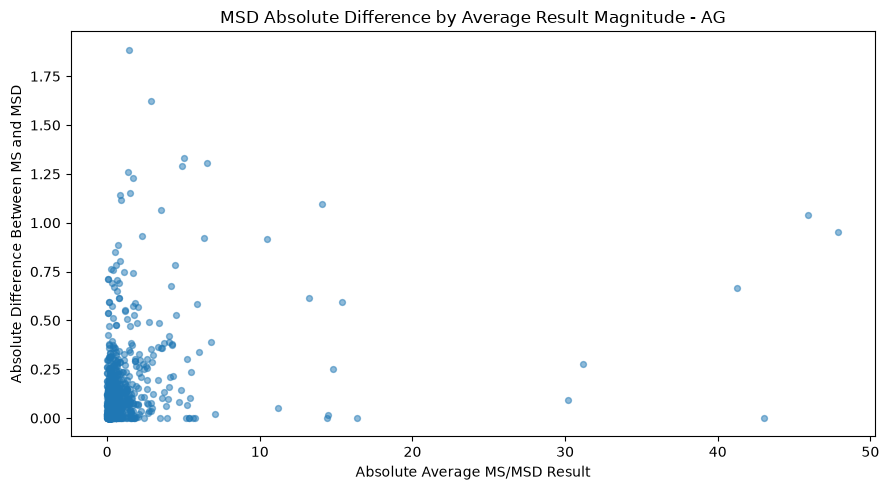

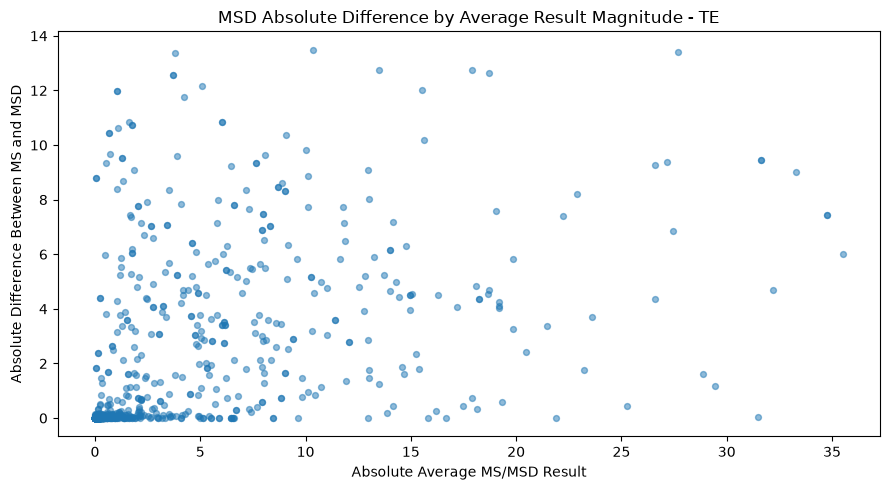

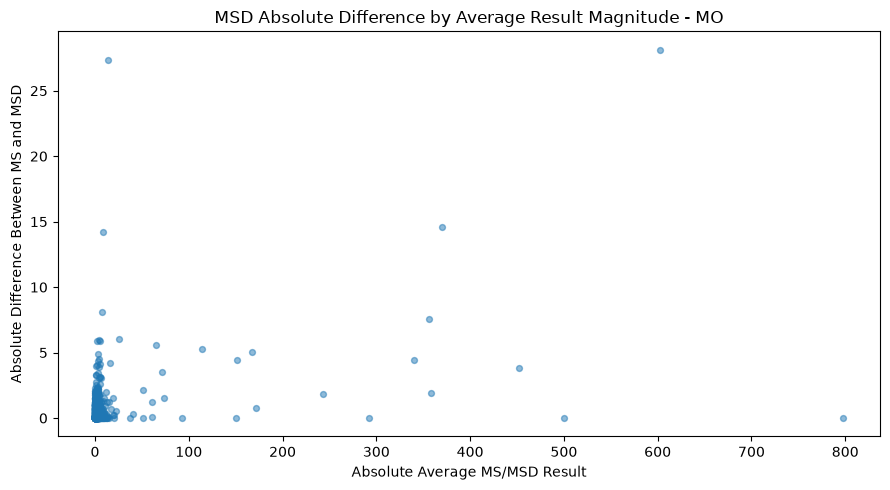

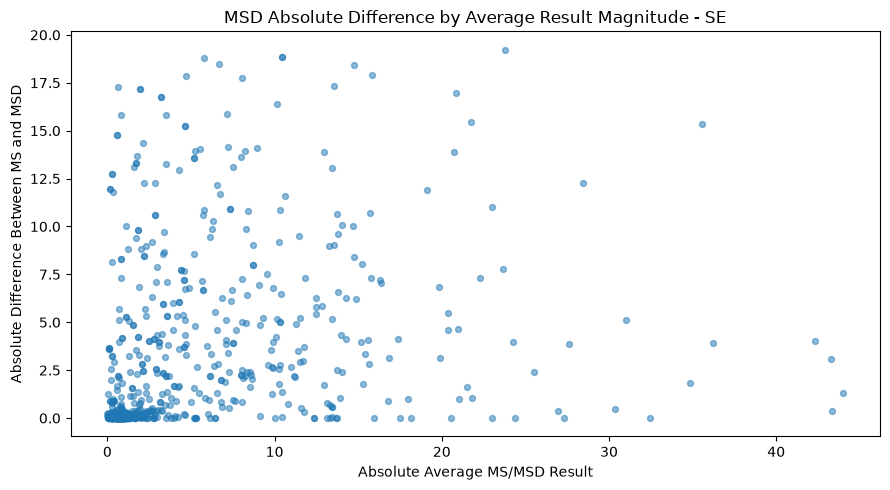

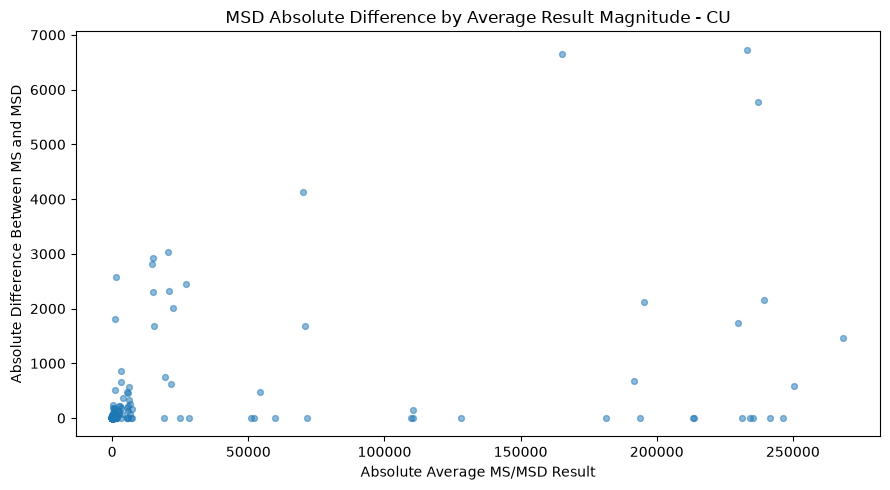

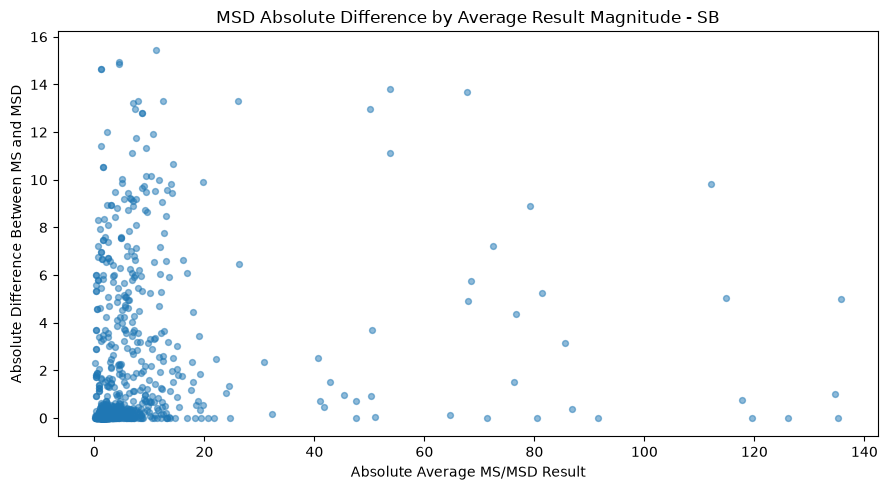

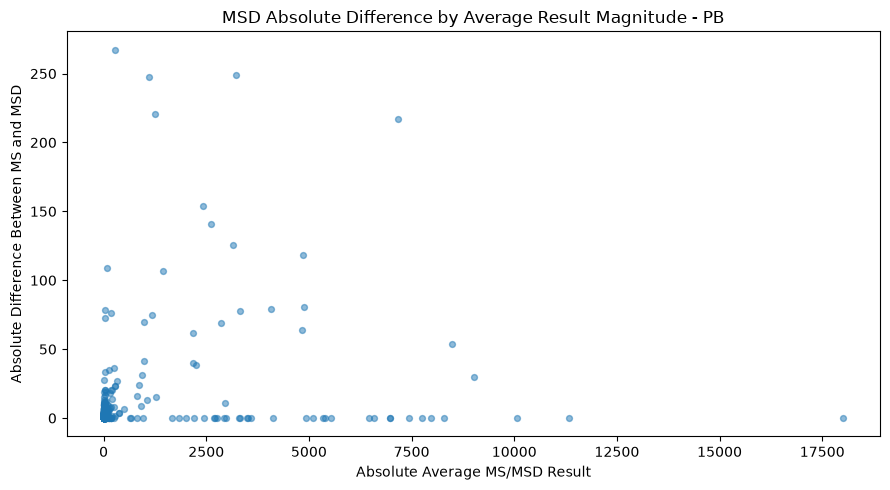

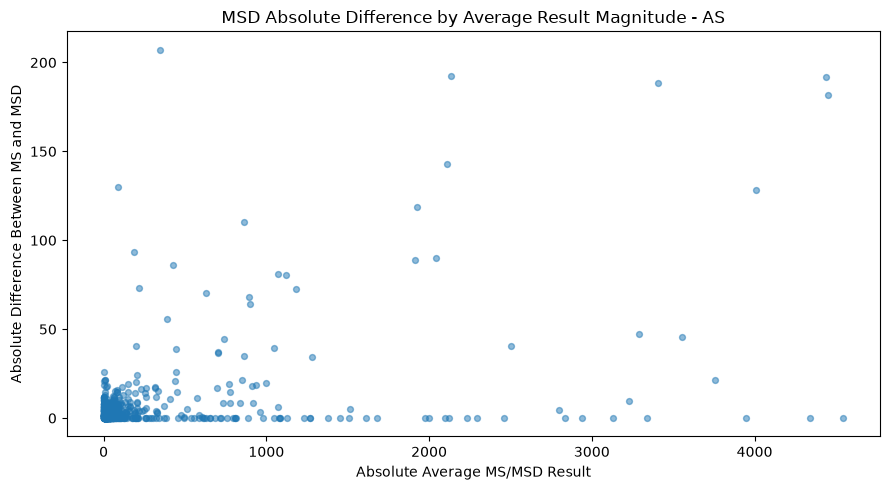

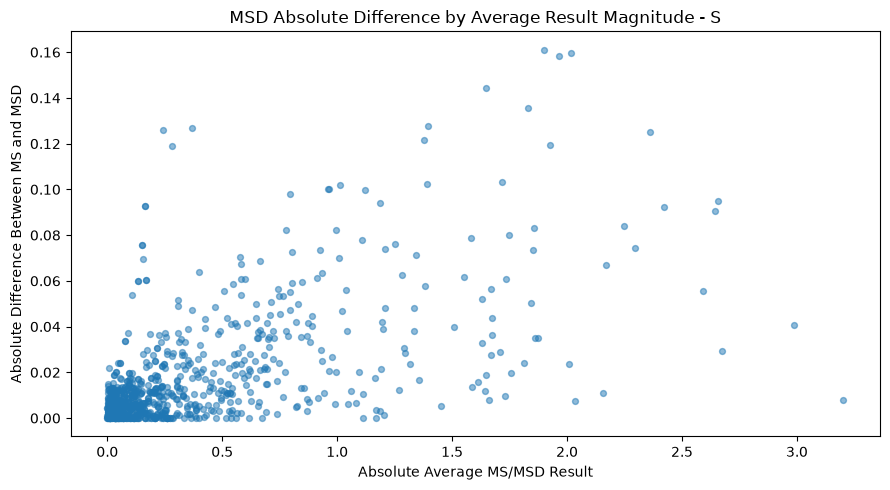

In [ ]:
# Prepare data for exploring MSD mean and variability behaviour

variability_data = msd[
    [
        "ANALYTE_CODE",
        "Avg",
        "AbsDiff"
    ]
].copy()

variability_data = variability_data.dropna(
    subset=[
        "ANALYTE_CODE",
        "Avg",
        "AbsDiff"
    ]
)

# Use absolute average result as result magnitude
variability_data["ABS_AVG"] = variability_data["Avg"].abs()

# Focus on analytes with the most observations
top_analytes = (
    variability_data["ANALYTE_CODE"]
    .value_counts()
    .head(10)
    .index
)

for analyte in top_analytes:

    analyte_data = variability_data[
        variability_data["ANALYTE_CODE"] == analyte
    ].copy()

    # Restrict displayed range to the 99th percentile for visual clarity.
    # This does not remove observations from the original dataset.
    x_limit = analyte_data["ABS_AVG"].quantile(0.99)
    y_limit = analyte_data["AbsDiff"].quantile(0.99)

    plot_data = analyte_data[
        (analyte_data["ABS_AVG"] <= x_limit) &
        (analyte_data["AbsDiff"] <= y_limit)
    ]

    plt.figure(figsize=(9, 5))

    plt.scatter(
        plot_data["ABS_AVG"],
        plot_data["AbsDiff"],
        alpha=0.5,
        s=18
    )

    plt.title(
        f"MSD Absolute Difference by Average Result Magnitude - {analyte}"
    )

    plt.xlabel("Absolute Average MS/MSD Result")
    plt.ylabel("Absolute Difference Between MS and MSD")

    plt.tight_layout()
    plt.show()

### Section 11 Findings

- The absolute difference between paired MS and MSD results varies substantially between analytes and across result magnitudes.
- Several analytes, including BI, AG, TE, SE and SB, show most paired differences concentrated near zero, with a smaller number of larger differences spread across the observed result range.
- The scale of paired-result variability differs strongly between analytes. For example, CU, PB and AS show much larger absolute differences because their measured result magnitudes are also much larger, while S operates on a much smaller numerical scale.
- There is no single consistent relationship between result magnitude and absolute difference across all analytes. Some analytes show wider differences at particular result magnitudes, while others remain relatively concentrated near zero.
- This demonstrates that MSD precision behaviour is analyte-specific and concentration-dependent, so a single fixed absolute-difference threshold would not describe all analytes appropriately.
- Large absolute differences visible in these plots should not automatically be treated as anomalies. Their significance depends on the analyte, the magnitude of the paired measurements, the relative percentage difference, and the relevant QC limits.
- These results support considering both the average MS/MSD result magnitude and the variability between the paired measurements when developing the later MSD anomaly-detection approach.

## 12. EDA Summary and Data Limitations

### Overall EDA Summary

The MSD dataset contains paired MS/MSD measurements with derived absolute and percentage differences, existing CCLAS precision classifications, warning and failure limits, analyte information, scheme information and analysed dates.

The exploratory analysis showed that:

- MSD precision behaviour differs substantially between analytes.
- The size of the difference between paired MS and MSD results depends partly on result magnitude.
- Percentage differences tend to be more variable at some result magnitudes than others.
- Existing CCLAS precision classifications provide useful context for understanding current rule-based MSD assessment.
- The supplied Status field can be reproduced from the supplied warning and failure limits.
- Paired MS and MSD measurements generally follow one another, although the amount of agreement differs between analytes.
- MSD precision behaviour also varies across scheme and analyte combinations.
- Historical plots show that the amount and frequency of large percentage differences vary through time and between analytes.

These findings indicate that MSD behaviour is context-dependent and that analyte, scheme, result magnitude and historical behaviour should be considered when developing later anomaly-detection methods.

### Data Limitations Identified During Exploration

- The available MSD assessment data does not contain an explicit recovery-percentage field, so recovery behaviour cannot be directly explored from this sheet without an approved calculation or additional source field.
- No clear batch identifier is available in the explored columns. Therefore, Datamine's stated concept of intermittent failures across batches cannot be assessed directly; analysed date can only be used to explore behaviour through time.
- No explicit sample-matrix or sample-composition field is available, so matrix heterogeneity or matrix instability cannot be directly determined from this dataset.
- Scheme and analyte differences can be described, but they should not be interpreted as proof of matrix effects.
- The exploratory plots describe unusual patterns and variability but do not by themselves identify anomalies or establish their causes.